# Inicialização

## Import de bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import collections
import seaborn as sns
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
from pprint import pprint

# from google.colab import drive

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.transforms import Bbox
from matplotlib.ticker import MaxNLocator

from sklearn import svm, tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split, StratifiedKFold
from sklearn.utils import shuffle
from sklearn.metrics import precision_score, recall_score, f1_score,accuracy_score,roc_curve,\
classification_report,confusion_matrix,auc
from sklearn.preprocessing import label_binarize, StandardScaler

pd.set_option('max_colwidth', 800)
# Funções de geração/self-healing dos dados derivados (rótulos e histórico
# consolidado), reaproveitadas dos scripts na raiz do repositório.
from gerar_rotulos_latencia import criar_arquivo_rotulos as criar_arquivo_rotulos_menor_latencia
from gerar_rotulos_banda import criar_arquivo_rotulos_maior_banda
from gerar_historico_fluxo import (
    consolidar_historico_telemetria,
    duplicar_dataset_por_categoria,
    criar_arquivo_rotulos_por_fluxo,
    CATEGORIAS_FLUXO,
)


## Setup de plotagem de gráficos

In [2]:
rotas = {
    1: { 'cor': '#00bf63', 'nome': 'Verde' },
    2: { 'cor': '#ff3131', 'nome': 'Vermelho' },
    3: { 'cor': '#2440f7', 'nome': 'Azul' },
    4: { 'cor': '#ffd735', 'nome': 'Amarelo' }
}

# plots saving/showing configurations
save_file_flag=True
show_IV_plot=True

In [3]:
# function to return key for any value

def get_key(val,mydict):
	for key, value in mydict.items():
		if val == value:
			return key

def count_label(labels,labels_dic):
    label_buf=collections.Counter(labels)
    counted_labels_dic={get_key(key1,labels_dic):value1 for key1,value1 in label_buf.items()}
    return counted_labels_dic

In [4]:
def lines_plot(df_i,save_path,title_str='',y_label='',x_label='',save_file=''):

    fig=plt.figure()
    for key in df_i.keys():
        plt.plot(np.arange(len(df_i[key])),df_i[key],marker='x',label=key)
    plt.xticks(np.arange(len(df_i[key])),list(map(str,np.arange(1,len(df_i[key])+1,1))))
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title_str)
    #plt.legend(loc="best",bbox_to_anchor=(0.6, 0.4), ncol=2)
    plt.legend(loc="best")
    plt.grid()
    if save_file:
         plt.savefig(f"{os.path.join(save_path, save_file)}", dpi=300, format='pdf', bbox_inches='tight')
    plt.show()


def create_boxplot(valu_vec,save_path,date_set,title_str='',y_label='',x_label='',save_file=''):

    meanpointprops = dict(marker='+', markeredgecolor='darkgoldenrod',markerfacecolor='red')
    medianprops = dict(linestyle='-', linewidth=1, color='red')

    pltbx=plt.boxplot(valu_vec, showfliers=False,labels=date_set,meanprops=meanpointprops,medianprops=medianprops,
            showmeans=True,patch_artist=True)
    means_vals = [item.get_ydata()[0] for item in pltbx['means']]
    plt.setp(pltbx['boxes'], color='blue',facecolor='white')
    plt.title("%s"%title_str)
    #plt.ylim(0,10)
    plt.ylabel(y_label)
    plt.xlabel(x_label)
    #plt.xticks(rotation = 45)
    legend_elements = [Line2D([0], [0], color='red', lw=1, label='Median'),
                    Line2D([0], [0], color='darkgoldenrod',marker='+',label='Mean'),
                  Line2D([0], [0], color='blue', lw=1, label='25%-75%'),
                   Line2D([0], [0], color='black', lw=1, label='9%-91%')]
    plt.legend(handles=legend_elements,loc='best',  fancybox=True, framealpha=1)
    plt.grid()
    if save_file:
         plt.savefig(f"{os.path.join(save_path, save_file)}", dpi=300, format='pdf', bbox_inches='tight')
    plt.show()
    return means_vals

#####################################################################################################################

def call_compute_color_position(ax,confusion_mat):
    for i in range(confusion_mat.shape[0]):
        for j in range(confusion_mat.shape[1]):
            ax.text(x=j, y=i,s=confusion_mat[i, j], va='center', ha='center', size='large')
    ax.tick_params(top=False, bottom=True,labeltop=False, labelbottom=True)
    #ax.tick_params(top=True, bottom=False,labeltop=True, labelbottom=False)
    return ax

def plot_matrix(conf_mat,class_labels,classifier,title_str='',save_path='', file_prefix='mc'):

    fig = plt.figure()
    axes = fig.add_subplot(111)
    cax=axes.matshow(conf_mat, cmap=plt.cm.YlGnBu, alpha=0.8)
    fig.colorbar(cax)
    axes=call_compute_color_position(axes,conf_mat)
    axes.set_xlabel('Predictions')
    axes.set_ylabel('Actuals')
    axes.set_title(f'{title_str}',fontsize=10)
    axes.set_xticklabels([''] + class_labels)
    axes.set_yticklabels([''] + class_labels)
    if save_path and file_prefix:
        os.makedirs(save_path, exist_ok=True)
        file_to_save=f"{file_prefix}_{classifier}.png"
        plt.savefig(f"{os.path.join(save_path, file_to_save)}", dpi=300, bbox_inches='tight')
    plt.show()

In [5]:
def plot_roc_curve(y_test_binarized, class_labels, classifier, y_pred_proba, title_str='', save_path='', save_file='', binary_classification=True):
    n_class = len(class_labels)

    if binary_classification:
        unique_classes = np.unique(y_test)
        y_test_binary = np.where(y_test == unique_classes[0], 0, 1)

        y_score = y_pred_proba[:, 1]

        fpr, tpr, _ = roc_curve(y_test_binary, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    else:
        unique_classes = np.unique(y_test)
        y_test_binarized = label_binarize(y_test, classes=unique_classes)

        if y_test_binarized.shape[1] == 1:
            y_test_binarized = np.hstack([1 - y_test_binarized, y_test_binarized])

        fpr = {}
        tpr = {}
        roc_auc = {}

        for i in range(n_class):
            fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            plt.plot(fpr[i], tpr[i], linestyle='--', linewidth=2,
                    label=f'{class_labels[i]} vs Rest (AUC = {roc_auc[i]:.3f})')

        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_pred_proba.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_class)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_class):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= n_class

        fpr["macro"] = all_fpr
        tpr["macro"] = mean_tpr
        roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

        # Plotar médias
        plt.plot(fpr["micro"], tpr["micro"],
                label=f'micro-average (AUC = {roc_auc["micro"]:.3f})',
                color="deeppink", linestyle="-.", linewidth=3)

        plt.plot(fpr["macro"], tpr["macro"],
                label=f'macro-average (AUC = {roc_auc["macro"]:.3f})',
                color="navy", linestyle="-.", linewidth=3)

    plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.5,
            label='Random Classifier')

    # Configurações do gráfico
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(title_str if title_str else f'{classifier} - ROC Curve', fontsize=14)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)

    # Salvar se necessário
    if save_file and save_path:
        file_to_save = f"{save_file}_{classifier}.pdf"
        full_path = os.path.join(save_path, file_to_save)
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"Gráfico salvo em: {full_path}")

    plt.show()
    plt.close()

In [6]:
def full_extent(ax, pad=0.0):
    """Get the full extent of an axes, including axes labels, tick labels, and
    titles."""
    # For text objects, we need to draw the figure first, otherwise the extents
    # are undefined.
    ax.figure.canvas.draw()
    items = ax.get_xticklabels() + ax.get_yticklabels()
#    items += [ax, ax.title, ax.xaxis.label, ax.yaxis.label]
    items += [ax, ax.title]
    bbox = Bbox.union([item.get_window_extent() for item in items])

    return bbox.expanded(0.98 + pad, 1.12 + pad)



def plot_Prob_Dist_OvR(class_labels,classifier,y_pred_proba,y_target,title_str='',save_path='',save_file=''):
    fig=plt.figure(figsize = (15, 4))
    bins = [i/20 for i in range(20)] + [1]
    roc_auc_ovr = {}
    prob_class_dic={}
    i=0
    for key,value in class_labels.items():
        class_binary = [1 if y == value else 0 for y in y_target]

        # Prepares an auxiliar dataframe to help with the plots
        prob_class_dic['class'] = class_binary
        prob_class_dic['prob'] = y_pred_proba[:, i]
        df_aux=pd.DataFrame(prob_class_dic)
        df_aux = df_aux.reset_index(drop = True)


        # Plots the probability distribution for the class and the rest
        ax = plt.subplot(1, 4, i+1)
        #fig=sns.histplot(x='prob',data = df_aux, color = 'b', hue = 'class',ax = ax, bins = bins).get_figure()
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        sns.histplot(x='prob',data = df_aux, color = 'b', hue = 'class',ax = ax, bins = bins)
        #ax.set_title(value)
        ax.legend([f"Class: {key}", "Rest"])
        ax.set_xlabel(f"P(x = {key})")
        i=i+1
        if save_file:
            extent = full_extent(ax).transformed(fig.dpi_scale_trans.inverted())
            file_to_save=f"{save_file}_{classifier}_{key}.pdf"
            fig.savefig(f"{os.path.join(save_path, file_to_save)}", dpi=350,bbox_inches=extent)

    plt.tight_layout()
    plt.show()

## Ambiente de avaliação dos modelos

In [7]:
# Definir modelos
models = [
    ('LogisticRegression', LogisticRegression(max_iter=1000)),
    ('KNeighbors', KNeighborsClassifier()),
    ('SVC', svm.SVC(probability=True)),
    ('DecisionTree', tree.DecisionTreeClassifier()),
    ('ExtraTrees', ExtraTreesClassifier()),
    ('RandomForest', RandomForestClassifier()),
    ('GaussianNB', GaussianNB())
]

pipelines = {}

for model_name, model in models:
        pipelines[model_name] = Pipeline(steps=[('classifier', model)])

In [8]:
def model_cross_validation(X_train, y_train, pipelines, folds=5, binary_classification=True):
    """
    Realiza validação cruzada nos dados de TREINO usando Stratified K-Fold
    Garante que cada dobra (fold) mantenha a proporção de classes
    """

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

    cv_results = []

    print("="*80)
    print("VALIDAÇÃO CRUZADA NO CONJUNTO DE TREINO (Stratified K-Fold)")
    print("="*80)

    for model_name, pipeline in pipelines.items():
        try:
            scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy')
            y_pred = cross_val_predict(pipeline, X_train, y_train, cv=skf, method='predict')
            y_predproba = cross_val_predict(pipeline, X_train, y_train, cv=skf, method='predict_proba')

            precision = precision_score(y_train, y_pred, average='macro', zero_division=0)
            recall = recall_score(y_train, y_pred, average='macro', zero_division=0)
            f1 = f1_score(y_train, y_pred, average='macro', zero_division=0)

            cv_results.append({
                'Model': model_name,
                'Acc_mean': f"{scores.mean():.4f}",
                'Acc_std': f"{scores.std():.4f}",
                'Precision': f"{precision:.4f}",
                'Recall': f"{recall:.4f}",
                'F1-Score': f"{f1:.4f}"
            })

            print(f"{model_name:20s} | Acc: {scores.mean():.4f} ± {scores.std():.4f}")

        except Exception as e:
            print(f"{model_name:20s} | ERRO: {str(e)}")
            cv_results.append({
                'Model': model_name,
                'Acc_mean': 'ERRO',
                'Acc_std': 'ERRO',
                'Precision': 'ERRO',
                'Recall': 'ERRO',
                'F1-Score': 'ERRO'
            })

    cv_df = pd.DataFrame(cv_results)
    return cv_df

In [9]:
def model_train(X_train, y_train, pipelines, model_dir='models'):
    # Treinar pipeline completo para uso posterior com dados de teste (não vistos).
    # model_dir é isolado por análise (latência/banda/multiobjetivo) para uma
    # análise não sobrescrever os modelos salvos pela outra.
    Path(model_dir).mkdir(parents=True, exist_ok=True)
    trained_pipelines = {}

    for model_name, pipeline in pipelines.items():
        pipeline.fit(X_train, y_train)
        trained_pipelines[model_name] = pipeline

        joblib.dump(pipeline, f'{model_dir}/{model_name}.pkl')

    return trained_pipelines

In [10]:
def evaluate_on_test(X_test, y_test, trained_pipelines, class_labels, binary_classification=True, result_path=''):
    # Avalia todos os modelos treinados no conjunto de TESTE

    lines = []

    def log(text=''):
        print(text)
        lines.append(str(text))

    log("="*80)
    log("AVALIAÇÃO NO CONJUNTO DE TESTE (DADOS NÃO VISTOS)")
    log("="*80 + "\n")

    class_labels_str = [str(label) for label in class_labels]
    test_results = []

    for model_name, pipeline in trained_pipelines.items():
        log(f"\n{'─'*80}")
        log(f"Modelo: {model_name}")
        log(f"{'─'*80}")

        try:
            y_pred = pipeline.predict(X_test)
            y_pred_proba = pipeline.predict_proba(X_test)

            accuracy  = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
            recall    = recall_score(y_test, y_pred, average='macro', zero_division=0)
            f1        = f1_score(y_test, y_pred, average='macro', zero_division=0)

            test_results.append({
                'Model': model_name,
                'Accuracy': f"{accuracy:.4f}",
                'Precision': f"{precision:.4f}",
                'Recall': f"{recall:.4f}",
                'F1-Score': f"{f1:.4f}"
            })

            log("\nRelatório de Classificação:")
            log(classification_report(y_test, y_pred,
                                      target_names=class_labels_str,
                                      labels=class_labels,
                                      zero_division=0))

            cm = confusion_matrix(y_test, y_pred, labels=class_labels)
            log("\nMatriz de Confusão:")
            log(cm)

            plot_matrix(cm, class_labels_str, model_name,
                        title_str=f'{model_name} - Conjunto de Teste',
                        save_path=result_path,
                        file_prefix='mc')

        except Exception as e:
            log(f"\nERRO ao avaliar {model_name}: {str(e)}")
            test_results.append({
                'Model': model_name,
                'Accuracy': 'ERRO', 'Precision': 'ERRO',
                'Recall': 'ERRO',   'F1-Score': 'ERRO'
            })

    log("\n" + "="*80)
    log("RELATÓRIO RESUMIDO - CONJUNTO DE TESTE")
    log("="*80)

    for result in test_results:
        log(f"{result['Model']:20s} | Acc: {result['Accuracy']}")

    log("="*80 + "\n")

    # Salvar summary.txt na mesma pasta das imagens
    summary_path = os.path.join(result_path, 'summary.txt')
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))

    test_df = pd.DataFrame(test_results)
    return test_df

In [11]:
def compare_train_test_performance(cv_df, test_df, result_path='./results'):
    """
    Compara performance entre validação cruzada (treino) e teste
    Lida com modelos que falharam (valores 'ERRO' ou 'N/A')
    """
    print("\n" + "="*80)
    print("COMPARAÇÃO: VALIDAÇÃO CRUZADA vs TESTE")
    print("="*80 + "\n")

    comparison = pd.DataFrame({
        'Model': cv_df['Model'],
        'CV_Accuracy': cv_df['Acc_mean'],
        'Test_Accuracy': test_df['Accuracy']
    })

    print(comparison.to_string(index=False))

    # Filtrar apenas modelos que funcionaram (sem 'ERRO' ou 'N/A')
    def is_valid_value(val):
        """Verifica se o valor é numérico válido"""
        if pd.isna(val):
            return False
        if isinstance(val, str) and val.upper() in ['ERRO', 'N/A', 'NAN']:
            return False
        try:
            float(val)
            return True
        except (ValueError, TypeError):
            return False

    # Criar máscara para linhas válidas
    valid_mask = (
        comparison['CV_Accuracy'].apply(is_valid_value) &
        comparison['Test_Accuracy'].apply(is_valid_value)
    )

    comparison_valid = comparison[valid_mask].copy()
    comparison_invalid = comparison[~valid_mask].copy()

    # Informar sobre modelos excluídos
    if len(comparison_invalid) > 0:
        print(f"\n⚠️  {len(comparison_invalid)} modelo(s) excluído(s) do gráfico por conter erros:")
        for model in comparison_invalid['Model']:
            print(f"   - {model}")

    # Verificar se há modelos válidos para plotar
    if len(comparison_valid) == 0:
        print("\nERRO: Nenhum modelo válido para comparação!")
        return comparison

    # Converter para float
    comparison_valid['CV_Accuracy'] = comparison_valid['CV_Accuracy'].astype(float)
    comparison_valid['Test_Accuracy'] = comparison_valid['Test_Accuracy'].astype(float)

    # Plotar comparação
    fig, ax = plt.subplots(figsize=(14, 5))

    models = comparison_valid['Model']
    x = np.arange(len(models))
    width = 0.35

    # Acurácia
    cv_acc = comparison_valid['CV_Accuracy'].values
    test_acc = comparison_valid['Test_Accuracy'].values

    bars1 = ax.bar(x - width/2, cv_acc, width, label='Validação Cruzada', alpha=0.8, color='skyblue')
    bars2 = ax.bar(x + width/2, test_acc, width, label='Teste', alpha=0.8, color='coral')

    # Adicionar valores nas barras
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xlabel('Modelo', fontsize=11)
    ax.set_ylabel('Acurácia', fontsize=11)
    ax.set_title('Comparação de Acurácia', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    ax.legend(loc='best')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])

    plt.tight_layout()

    save_path = f"{result_path}/comparacao_treino_vs_teste.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

    # Análise de overfitting
    print("\n" + "="*80)
    print("ANÁLISE DE OVERFITTING")
    print("="*80)

    for idx, row in comparison_valid.iterrows():
        model = row['Model']
        cv_acc = row['CV_Accuracy']
        test_acc = row['Test_Accuracy']
        diff = cv_acc - test_acc

        print(f"{model:20s} | CV: {cv_acc:.4f} | Test: {test_acc:.4f} | Diff: {diff:+.4f}")

    return comparison

# Carregamento do dataset
Atualize `DATASET` para escolher o cenário desejado.

In [12]:
# Se "True", descomente o import do Google Drive e garanta que o pacote esteja instalado no ambiente
TEST_ON_COLAB = False

DATASET_FOLDER = 'datasets'
RESULTS_FOLDER = 'resultados_am'
DATASET = 'D2'

if TEST_ON_COLAB:
    pasta_dataset = f"/content/drive/MyDrive/{DATASET_FOLDER}/{DATASET}"
    drive.mount("/content/drive")
else:
    pasta_dataset = f"{DATASET_FOLDER}/{DATASET}"

os.makedirs(pasta_dataset, exist_ok=True)
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Arquivos usados pelas três análises abaixo (latência, banda e múltiplos
# objetivos). Cada análise define seu próprio pasta_resultados_*.
arquivo_latencia_csv = 'latencia_rotas_h1_h6.csv'
arquivo_banda_csv = 'banda_rotas_h1_h6.csv'
arquivo_rotulos_latencia = 'rotulos_menor_latencia.txt'
arquivo_rotulos_banda = 'rotulos_maior_banda.txt'
arquivo_historico_fluxo = 'historico_telemetria_h1_h6.csv'
arquivo_rotulos_fluxo = 'rotulos_por_fluxo.txt'


## Self-healing dos dados derivados

Alguns cenários em `datasets/` têm apenas os CSVs consolidados de latência e banda. Os arquivos derivados (rótulos de menor latência, rótulos de maior banda, histórico consolidado e rótulos por fluxo) são gerados automaticamente aqui se estiverem faltando ou incompletos, reaproveitando as funções de `gerar_rotulos_latencia.py`, `gerar_rotulos_banda.py` e `gerar_historico_fluxo.py`.

Isso não cobre a ausência dos próprios CSVs consolidados (`latencia_rotas_h1_h6.csv` / `banda_rotas_h1_h6.csv`): sem eles não há como reconstruir os dados a partir daqui, e uma exceção clara é levantada em vez de o notebook falhar mais adiante de forma confusa.

In [13]:
def garantir_dataset_pronto(pasta_dataset):
    caminho_latencia = os.path.join(pasta_dataset, arquivo_latencia_csv)
    caminho_banda = os.path.join(pasta_dataset, arquivo_banda_csv)

    if not (os.path.isfile(caminho_latencia) and os.path.isfile(caminho_banda)):
        raise FileNotFoundError(
            f"'{pasta_dataset}' precisa conter {arquivo_latencia_csv} e {arquivo_banda_csv}; "
            "sem eles não é possível gerar os dados automaticamente."
        )

    caminho_rotulos_latencia = os.path.join(pasta_dataset, arquivo_rotulos_latencia)
    if not os.path.isfile(caminho_rotulos_latencia):
        print(f"[self-healing] Gerando {arquivo_rotulos_latencia}...")
        criar_arquivo_rotulos_menor_latencia(pasta_dataset, arquivo_latencia_csv, arquivo_rotulos_latencia)

    caminho_rotulos_banda = os.path.join(pasta_dataset, arquivo_rotulos_banda)
    if not os.path.isfile(caminho_rotulos_banda):
        print(f"[self-healing] Gerando {arquivo_rotulos_banda}...")
        criar_arquivo_rotulos_maior_banda(pasta_dataset, arquivo_banda_csv, arquivo_rotulos_banda)

    caminho_historico = os.path.join(pasta_dataset, arquivo_historico_fluxo)
    caminho_rotulos_fluxo = os.path.join(pasta_dataset, arquivo_rotulos_fluxo)

    historico_pronto = os.path.isfile(caminho_historico) and os.path.isfile(caminho_rotulos_fluxo)
    if historico_pronto:
        with open(caminho_historico) as f:
            historico_pronto = 'categoria' in f.readline()

    if not historico_pronto:
        print(f"[self-healing] Gerando {arquivo_historico_fluxo} e {arquivo_rotulos_fluxo}...")
        consolidar_historico_telemetria(pasta_dataset, arquivo_latencia_csv, arquivo_banda_csv, arquivo_historico_fluxo)
        duplicar_dataset_por_categoria(pasta_dataset, arquivo_historico_fluxo, list(CATEGORIAS_FLUXO.keys()))
        criar_arquivo_rotulos_por_fluxo(pasta_dataset, arquivo_historico_fluxo, arquivo_rotulos_fluxo, CATEGORIAS_FLUXO)

garantir_dataset_pronto(pasta_dataset)
print(f"\nDataset '{DATASET}' pronto em: {pasta_dataset}")



Dataset 'D2' pronto em: datasets/D2


# Análise de Latência

In [14]:
historico_latencia = pd.read_csv(f"{pasta_dataset}/{arquivo_latencia_csv}")

faltantes_latencia = historico_latencia.iloc[:, 1:].isna().sum().sum()
if faltantes_latencia:
    print(f"Aviso: {faltantes_latencia} valores de latência faltantes — preenchidos por interpolação linear.")
    historico_latencia.iloc[:, 1:] = historico_latencia.iloc[:, 1:].interpolate(method='linear', limit_direction='both')

rotulos_lat = np.loadtxt(f"{pasta_dataset}/{arquivo_rotulos_latencia}", comments='#', dtype=int)

latencia_por_rota = historico_latencia.iloc[:, 1:].values

datetimes_lat = historico_latencia.iloc[:, 0].values
datetimes_lat_dt = pd.to_datetime(datetimes_lat)

temporal_features_lat = np.column_stack([
    datetimes_lat_dt.hour,
    datetimes_lat_dt.minute,
    datetimes_lat_dt.second,
    datetimes_lat_dt.day,
    datetimes_lat_dt.month,
    datetimes_lat_dt.year
])

print(datetimes_lat[:5], '\n')
print(temporal_features_lat[:5], '\n')
print(latencia_por_rota[:5], '\n')
print(rotulos_lat[:5])


<StringArray>
['2025-11-26 09:50:17', '2025-11-26 09:50:18', '2025-11-26 09:50:19',
 '2025-11-26 09:50:20', '2025-11-26 09:50:21']
Length: 5, dtype: str 

[[   9   50   17   26   11 2025]
 [   9   50   18   26   11 2025]
 [   9   50   19   26   11 2025]
 [   9   50   20   26   11 2025]
 [   9   50   21   26   11 2025]] 

[[24.96291004 36.23178991 22.43566547 19.34241361]
 [24.00283623 34.79592894 21.79664958 18.79260389]
 [24.         35.08746972 22.18643918 19.08827817]
 [24.         35.1        22.29659758 19.1       ]
 [24.         35.00419371 22.20340329 19.00413029]] 

[4 4 4 4 4]


In [15]:
X_lat = np.hstack([temporal_features_lat, latencia_por_rota])
y_lat = rotulos_lat

pathIds_lat = list(range(1, latencia_por_rota.shape[1] + 1))
n_classes_lat = len(pathIds_lat)

print(f"Shape: {X_lat.shape}")
print(pathIds_lat, n_classes_lat)


Shape: (3660, 10)
[1, 2, 3, 4] 4


## Análise do dataset (latência)

In [16]:
classes_lat = {}
for pathId in pathIds_lat:
    nome = rotas[pathId]["nome"]
    classes_lat[nome] = pathId

print(classes_lat)


{'Verde': 1, 'Vermelho': 2, 'Azul': 3, 'Amarelo': 4}


In [17]:
d_lat = {  'rotulos': pd.Series(rotulos_lat),
	   'latencias': pd.Series(latencia_por_rota.tolist()) }

df_lat = pd.DataFrame(d_lat)

print("Numero de linhas: ", df_lat.shape[0])
print("Qtd Rótulos: ", rotulos_lat.shape)
print("Qtd Latências: ", df_lat['latencias'].shape)

print(df_lat['rotulos'].value_counts())


Numero de linhas:  3660
Qtd Rótulos:  (3660,)
Qtd Latências:  (3660,)
rotulos
4    3051
3     400
1     196
2      13
Name: count, dtype: int64


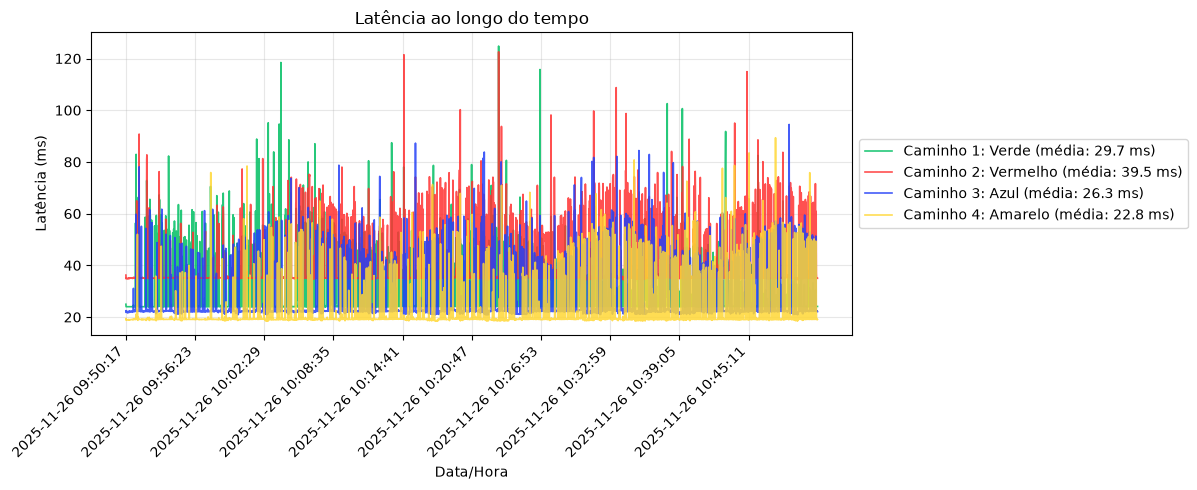

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

for pathId in pathIds_lat:
    propriedades = rotas[pathId]
    nome = propriedades["nome"]
    cor = propriedades["cor"]

    media = np.nanmean(latencia_por_rota[:, pathId - 1])
    ax.plot(
        datetimes_lat, latencia_por_rota[:, pathId - 1],
        label=f'Caminho {pathId}: {nome} (média: {media:.1f} ms)',
        color=cor, linewidth=1.2, alpha=0.85
    )

step = max(1, len(datetimes_lat) // 10)  # mostra +- 10 datas no eixo
ax.set_xticks(datetimes_lat[::step])
ax.set_xticklabels(datetimes_lat[::step], rotation=45, ha='right')

ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
ax.set_xlabel('Data/Hora')
ax.set_ylabel('Latência (ms)')
ax.set_title('Latência ao longo do tempo')
plt.tight_layout()
plt.show()


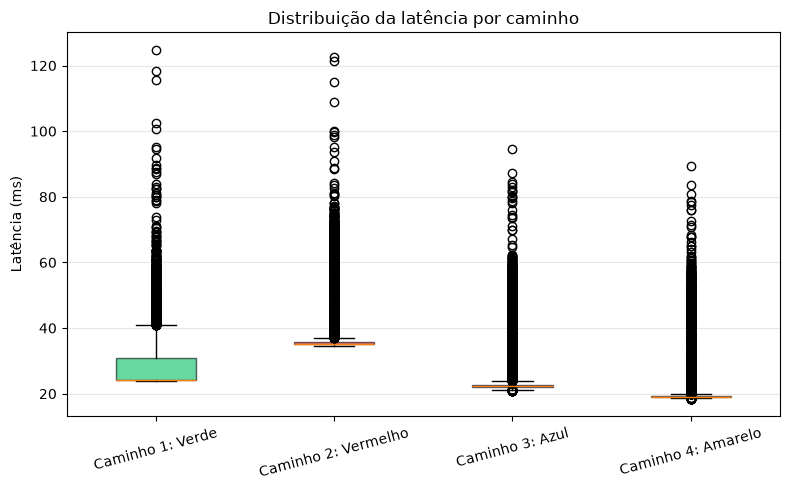

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

dados_boxplot_lat = [latencia_por_rota[:, pathId - 1] for pathId in pathIds_lat]
cores_lat = [rotas[pathId]['cor'] for pathId in pathIds_lat]
labels_boxplot_lat = [f"Caminho {pathId}: {rotas[pathId]['nome']}" for pathId in pathIds_lat]

caixas = ax.boxplot(dados_boxplot_lat, tick_labels=labels_boxplot_lat, patch_artist=True)
for caixa, cor in zip(caixas['boxes'], cores_lat):
    caixa.set_facecolor(cor)
    caixa.set_alpha(0.6)

ax.set_ylabel('Latência (ms)')
ax.set_title('Distribuição da latência por caminho')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Pipeline (latência)

1.   Separação dos dados entre treino e teste (80% : 20%)
2.   Validação cruzada dos modelos com o conjunto de treino, com estratificação
3.   Treinamento dos modelos com o conjunto de treino
4.   Teste dos modelos com o conjunto de teste
5.   Comparação de desempenho entre treino (validação cruzada) e teste

In [20]:
pasta_resultados_lat = f"{RESULTS_FOLDER}/CenarioLatencia_{DATASET}"
os.makedirs(pasta_resultados_lat, exist_ok=True)

rotulos_dataset_lat = np.unique(y_lat).tolist()
binaryClassification_lat = len(rotulos_dataset_lat) <= 2

X_train_lat, X_test_lat, y_train_lat, y_test_lat = train_test_split(
    X_lat, y_lat,
    test_size=0.2,
    random_state=1234,
    shuffle=True,
    stratify=None
)

print(f"Total de amostras: {len(y_lat)}\n")
print(f"Classes únicas:\t\t{rotulos_dataset_lat}")
print(f"Classes em y_train_lat:\t{np.unique(y_train_lat)}")
print(f"Classes em y_test_lat:\t{np.unique(y_test_lat)}")
print("\nDistribuição das classes:")
print(pd.Series(y_lat).value_counts())


Total de amostras: 3660

Classes únicas:		[1, 2, 3, 4]
Classes em y_train_lat:	[1 2 3 4]
Classes em y_test_lat:	[1 2 3 4]

Distribuição das classes:
4    3051
3     400
1     196
2      13
Name: count, dtype: int64


VALIDAÇÃO CRUZADA NO CONJUNTO DE TREINO (Stratified K-Fold)


LogisticRegression   | Acc: 0.9959 ± 0.0017


KNeighbors           | Acc: 0.9553 ± 0.0096


SVC                  | Acc: 0.8327 ± 0.0001
DecisionTree         | Acc: 0.9891 ± 0.0038


ExtraTrees           | Acc: 0.9860 ± 0.0058


RandomForest         | Acc: 0.9898 ± 0.0032
GaussianNB           | Acc: 0.9255 ± 0.0153


AVALIAÇÃO NO CONJUNTO DE TESTE (DADOS NÃO VISTOS)


────────────────────────────────────────────────────────────────────────────────
Modelo: LogisticRegression
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.98      1.00      0.99        44
           2       1.00      0.50      0.67         2
           3       1.00      1.00      1.00        73
           4       1.00      1.00      1.00       613

    accuracy                           1.00       732
   macro avg       0.99      0.88      0.91       732
weighted avg       1.00      1.00      1.00       732


Matriz de Confusão:
[[ 44   0   0   0]
 [  1   1   0   0]
 [  0   0  73   0]
 [  0   0   0 613]]


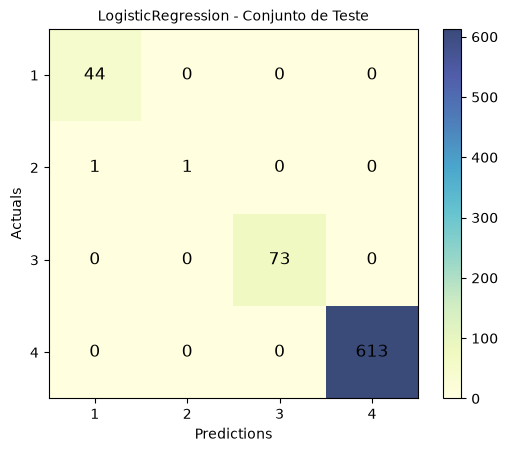


────────────────────────────────────────────────────────────────────────────────
Modelo: KNeighbors
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.94      0.75      0.84        44
           2       0.00      0.00      0.00         2
           3       0.92      0.79      0.85        73
           4       0.97      1.00      0.98       613

    accuracy                           0.96       732
   macro avg       0.71      0.64      0.67       732
weighted avg       0.96      0.96      0.96       732


Matriz de Confusão:
[[ 33   0   5   6]
 [  2   0   0   0]
 [  0   0  58  15]
 [  0   0   0 613]]


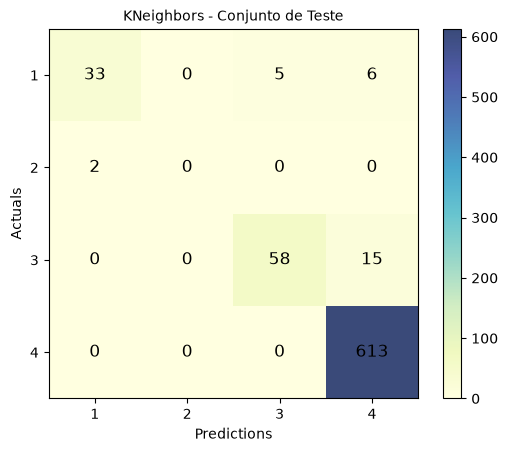


────────────────────────────────────────────────────────────────────────────────
Modelo: SVC
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        44
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00        73
           4       0.84      1.00      0.91       613

    accuracy                           0.84       732
   macro avg       0.21      0.25      0.23       732
weighted avg       0.70      0.84      0.76       732


Matriz de Confusão:
[[  0   0   0  44]
 [  0   0   0   2]
 [  0   0   0  73]
 [  0   0   0 613]]


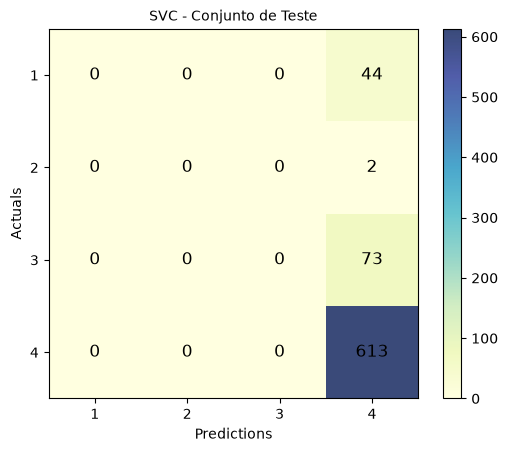


────────────────────────────────────────────────────────────────────────────────
Modelo: DecisionTree
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       1.00      0.95      0.98        44
           2       1.00      1.00      1.00         2
           3       0.97      0.97      0.97        73
           4       0.99      1.00      1.00       613

    accuracy                           0.99       732
   macro avg       0.99      0.98      0.99       732
weighted avg       0.99      0.99      0.99       732


Matriz de Confusão:
[[ 42   0   0   2]
 [  0   2   0   0]
 [  0   0  71   2]
 [  0   0   2 611]]


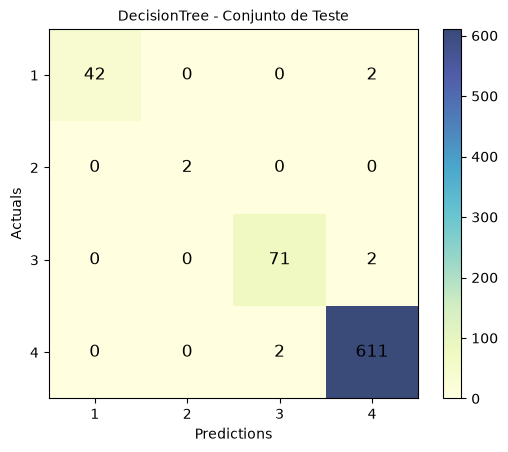


────────────────────────────────────────────────────────────────────────────────
Modelo: ExtraTrees
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.97      0.89      0.93        44
           2       1.00      0.50      0.67         2
           3       0.95      0.97      0.96        73
           4       0.99      1.00      1.00       613

    accuracy                           0.99       732
   macro avg       0.98      0.84      0.89       732
weighted avg       0.99      0.99      0.99       732


Matriz de Confusão:
[[ 39   0   3   2]
 [  1   1   0   0]
 [  0   0  71   2]
 [  0   0   1 612]]


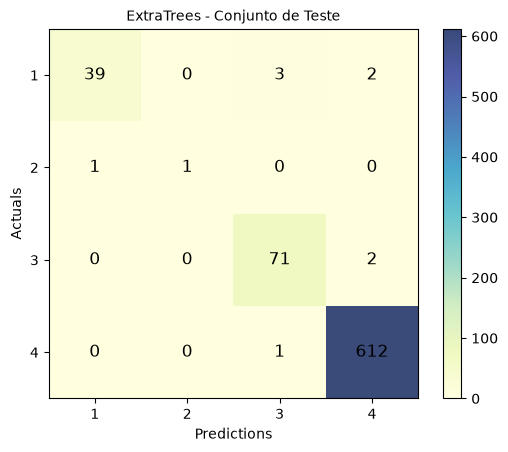


────────────────────────────────────────────────────────────────────────────────
Modelo: RandomForest
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.98      0.98      0.98        44
           2       1.00      0.50      0.67         2
           3       0.95      0.99      0.97        73
           4       1.00      1.00      1.00       613

    accuracy                           0.99       732
   macro avg       0.98      0.86      0.90       732
weighted avg       0.99      0.99      0.99       732


Matriz de Confusão:
[[ 43   0   1   0]
 [  1   1   0   0]
 [  0   0  72   1]
 [  0   0   3 610]]


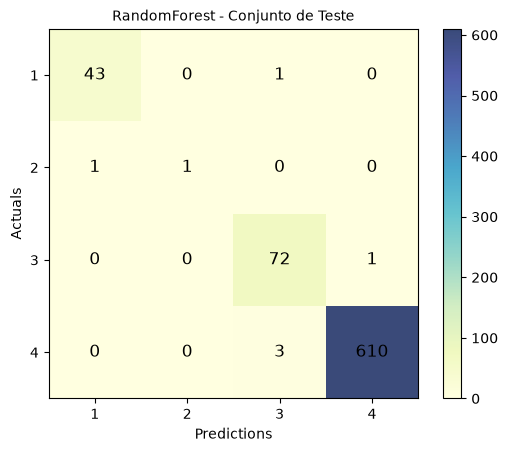


────────────────────────────────────────────────────────────────────────────────
Modelo: GaussianNB
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.69      0.45      0.55        44
           2       0.07      1.00      0.12         2
           3       0.79      0.93      0.86        73
           4       1.00      0.96      0.98       613

    accuracy                           0.92       732
   macro avg       0.64      0.84      0.63       732
weighted avg       0.96      0.92      0.94       732


Matriz de Confusão:
[[ 20  21   3   0]
 [  0   2   0   0]
 [  0   4  68   1]
 [  9   3  15 586]]


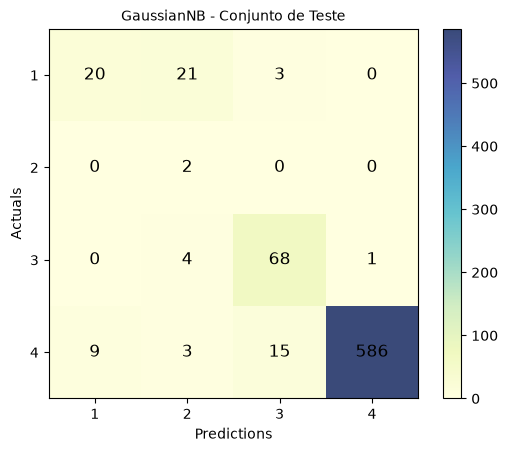


RELATÓRIO RESUMIDO - CONJUNTO DE TESTE
LogisticRegression   | Acc: 0.9986
KNeighbors           | Acc: 0.9617
SVC                  | Acc: 0.8374
DecisionTree         | Acc: 0.9918
ExtraTrees           | Acc: 0.9877
RandomForest         | Acc: 0.9918
GaussianNB           | Acc: 0.9235


COMPARAÇÃO: VALIDAÇÃO CRUZADA vs TESTE

             Model CV_Accuracy Test_Accuracy
LogisticRegression      0.9959        0.9986
        KNeighbors      0.9553        0.9617
               SVC      0.8327        0.8374
      DecisionTree      0.9891        0.9918
        ExtraTrees      0.9860        0.9877
      RandomForest      0.9898        0.9918
        GaussianNB      0.9255        0.9235


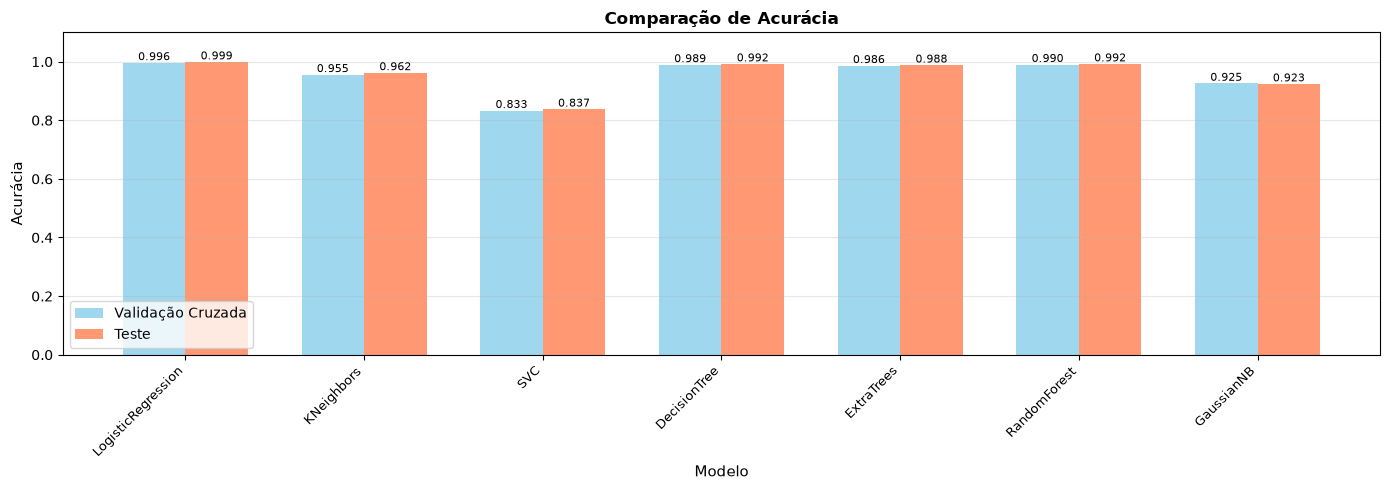


ANÁLISE DE OVERFITTING
LogisticRegression   | CV: 0.9959 | Test: 0.9986 | Diff: -0.0027
KNeighbors           | CV: 0.9553 | Test: 0.9617 | Diff: -0.0064
SVC                  | CV: 0.8327 | Test: 0.8374 | Diff: -0.0047
DecisionTree         | CV: 0.9891 | Test: 0.9918 | Diff: -0.0027
ExtraTrees           | CV: 0.9860 | Test: 0.9877 | Diff: -0.0017
RandomForest         | CV: 0.9898 | Test: 0.9918 | Diff: -0.0020
GaussianNB           | CV: 0.9255 | Test: 0.9235 | Diff: +0.0020


,Model,CV_Accuracy,Test_Accuracy
0,LogisticRegression,0.9959,0.9986
1,KNeighbors,0.9553,0.9617
2,SVC,0.8327,0.8374
3,DecisionTree,0.9891,0.9918
4,ExtraTrees,0.9860,0.9877
5,RandomForest,0.9898,0.9918
6,GaussianNB,0.9255,0.9235


In [21]:
resultados_cv_lat = model_cross_validation(X_train_lat, y_train_lat, pipelines, folds=5, binary_classification=binaryClassification_lat)
trained_pipelines_lat = model_train(X_train_lat, y_train_lat, pipelines, model_dir=f'{pasta_resultados_lat}/models')
test_results_lat = evaluate_on_test(
    X_test_lat,
    y_test_lat,
    trained_pipelines_lat,
    rotulos_dataset_lat,
    binary_classification=binaryClassification_lat,
    result_path=pasta_resultados_lat
)
compare_train_test_performance(resultados_cv_lat, test_results_lat, result_path=pasta_resultados_lat)


# Análise de Banda

In [22]:
historico_banda = pd.read_csv(f"{pasta_dataset}/{arquivo_banda_csv}")

# Algumas leituras de banda podem faltar pontualmente para uma rota (coleta
# feita em processo separado da latência); preenche por interpolação linear
# para não propagar NaN para os gráficos e para o treinamento dos modelos.
faltantes_banda = historico_banda.iloc[:, 1:].isna().sum().sum()
if faltantes_banda:
    print(f"Aviso: {faltantes_banda} valores de banda faltantes — preenchidos por interpolação linear.")
    historico_banda.iloc[:, 1:] = historico_banda.iloc[:, 1:].interpolate(method='linear', limit_direction='both')

rotulos_banda = np.loadtxt(f"{pasta_dataset}/{arquivo_rotulos_banda}", comments='#', dtype=int)

banda_por_rota = historico_banda.iloc[:, 1:].values

datetimes_banda = historico_banda.iloc[:, 0].values
datetimes_banda_dt = pd.to_datetime(datetimes_banda)

temporal_features_banda = np.column_stack([
    datetimes_banda_dt.hour,
    datetimes_banda_dt.minute,
    datetimes_banda_dt.second,
    datetimes_banda_dt.day,
    datetimes_banda_dt.month,
    datetimes_banda_dt.year
])

print(datetimes_banda[:5], '\n')
print(temporal_features_banda[:5], '\n')
print(banda_por_rota[:5], '\n')
print(rotulos_banda[:5])


Aviso: 2 valores de banda faltantes — preenchidos por interpolação linear.
<StringArray>
['2025-11-26 09:50:16', '2025-11-26 09:50:17', '2025-11-26 09:50:18',
 '2025-11-26 09:50:19', '2025-11-26 09:50:20']
Length: 5, dtype: str 

[[   9   50   16   26   11 2025]
 [   9   50   17   26   11 2025]
 [   9   50   18   26   11 2025]
 [   9   50   19   26   11 2025]
 [   9   50   20   26   11 2025]] 

[[100.         100.         100.         100.        ]
 [ 99.99412537  99.99487305  99.99487305  99.99412537]
 [ 99.99700928  99.99700928  99.99700928  99.99700928]
 [ 99.99700928  99.99700928  99.99700928  99.99700928]
 [ 99.99700928  99.99700928  99.99700928  99.99700928]] 

[1 2 1 1 1]


In [23]:
X_banda = np.hstack([temporal_features_banda, banda_por_rota])
y_banda = rotulos_banda

pathIds_banda = list(range(1, banda_por_rota.shape[1] + 1))
n_classes_banda = len(pathIds_banda)

print(f"Shape: {X_banda.shape}")
print(pathIds_banda, n_classes_banda)


Shape: (3659, 10)
[1, 2, 3, 4] 4


## Análise do dataset (banda)

In [24]:
classes_banda = {}
for pathId in pathIds_banda:
    nome = rotas[pathId]["nome"]
    classes_banda[nome] = pathId

print(classes_banda)


{'Verde': 1, 'Vermelho': 2, 'Azul': 3, 'Amarelo': 4}


In [25]:
d_banda = {  'rotulos': pd.Series(rotulos_banda),
	   'banda': pd.Series(banda_por_rota.tolist()) }

df_banda = pd.DataFrame(d_banda)

print("Numero de linhas: ", df_banda.shape[0])
print("Qtd Rótulos: ", rotulos_banda.shape)
print("Qtd Bandas: ", df_banda['banda'].shape)

print(df_banda['rotulos'].value_counts())


Numero de linhas:  3659
Qtd Rótulos:  (3659,)
Qtd Bandas:  (3659,)
rotulos
1    2095
3    1157
2     383
4      24
Name: count, dtype: int64


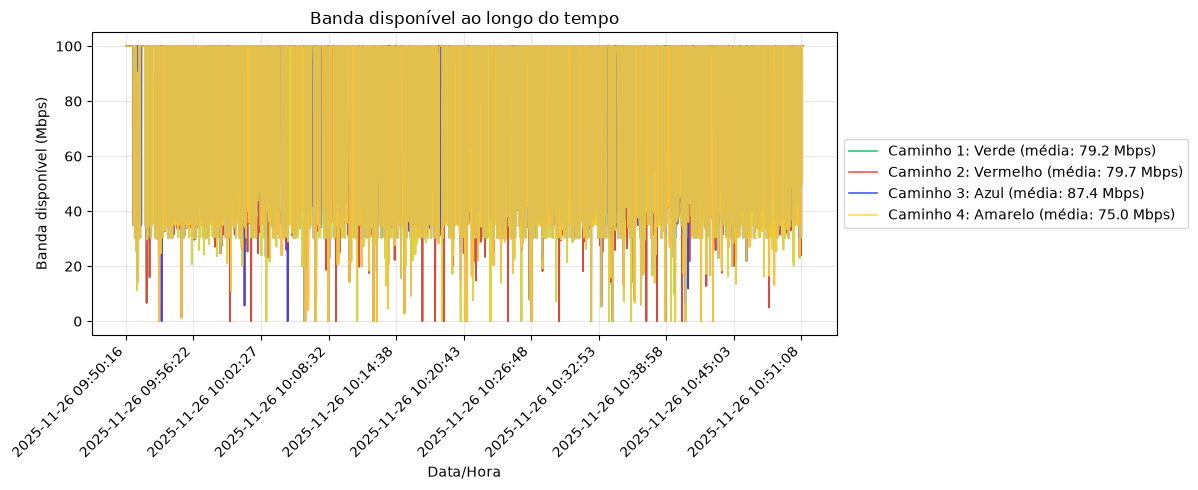

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))

for pathId in pathIds_banda:
    propriedades = rotas[pathId]
    nome = propriedades["nome"]
    cor = propriedades["cor"]

    media = np.nanmean(banda_por_rota[:, pathId - 1])
    ax.plot(
        datetimes_banda, banda_por_rota[:, pathId - 1],
        label=f'Caminho {pathId}: {nome} (média: {media:.1f} Mbps)',
        color=cor, linewidth=1.2, alpha=0.85
    )

step = max(1, len(datetimes_banda) // 10)  # mostra +- 10 datas no eixo
ax.set_xticks(datetimes_banda[::step])
ax.set_xticklabels(datetimes_banda[::step], rotation=45, ha='right')

# Desativa a notação de offset do matplotlib (ex.: "+9.999e1"), que em datasets com
# pouca variação (ex: D1, banda quase toda entre 99.99 e 100 Mbps) deixava o eixo Y
# confuso. Mostra os valores reais diretamente, mantendo o zoom automático nos dados.
ax.ticklabel_format(axis='y', style='plain', useOffset=False)

banda_min, banda_max = np.nanmin(banda_por_rota), np.nanmax(banda_por_rota)
margem = max(1.0, (banda_max - banda_min) * 0.05)
ax.set_ylim(banda_min - margem, banda_max + margem)
ax.grid(True, alpha=0.3)

ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
ax.set_xlabel('Data/Hora')
ax.set_ylabel('Banda disponível (Mbps)')
ax.set_title('Banda disponível ao longo do tempo')
plt.tight_layout()
plt.show()


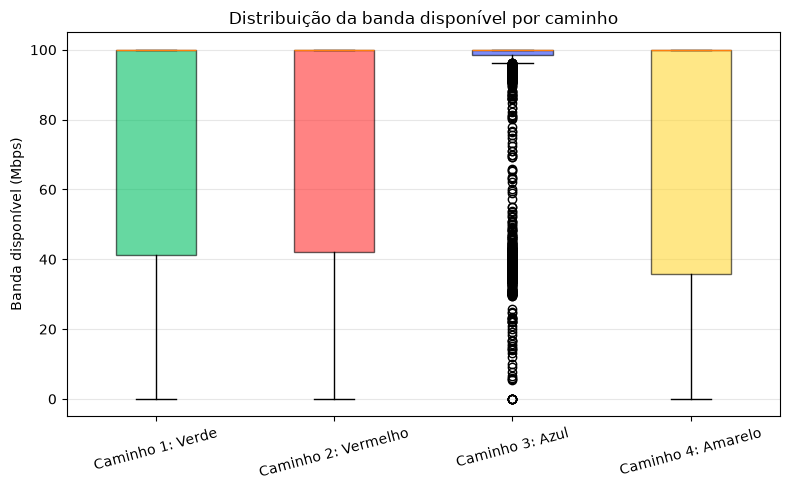

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

dados_boxplot_banda = [banda_por_rota[:, pathId - 1] for pathId in pathIds_banda]
cores_banda = [rotas[pathId]['cor'] for pathId in pathIds_banda]
labels_boxplot_banda = [f"Caminho {pathId}: {rotas[pathId]['nome']}" for pathId in pathIds_banda]

caixas = ax.boxplot(dados_boxplot_banda, tick_labels=labels_boxplot_banda, patch_artist=True)
for caixa, cor in zip(caixas['boxes'], cores_banda):
    caixa.set_facecolor(cor)
    caixa.set_alpha(0.6)

ax.set_ylabel('Banda disponível (Mbps)')
ax.set_title('Distribuição da banda disponível por caminho')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Pipeline (banda)

In [28]:
pasta_resultados_banda = f"{RESULTS_FOLDER}/CenarioBanda_{DATASET}"
os.makedirs(pasta_resultados_banda, exist_ok=True)

rotulos_dataset_banda = np.unique(y_banda).tolist()
binaryClassification_banda = len(rotulos_dataset_banda) <= 2

X_train_banda, X_test_banda, y_train_banda, y_test_banda = train_test_split(
    X_banda, y_banda,
    test_size=0.2,
    random_state=1234,
    shuffle=True,
    stratify=None
)

print(f"Total de amostras: {len(y_banda)}\n")
print(f"Classes únicas:\t\t{rotulos_dataset_banda}")
print(f"Classes em y_train_banda:\t{np.unique(y_train_banda)}")
print(f"Classes em y_test_banda:\t{np.unique(y_test_banda)}")
print("\nDistribuição das classes:")
print(pd.Series(y_banda).value_counts())


Total de amostras: 3659

Classes únicas:		[1, 2, 3, 4]
Classes em y_train_banda:	[1 2 3 4]
Classes em y_test_banda:	[1 2 3 4]

Distribuição das classes:
1    2095
3    1157
2     383
4      24
Name: count, dtype: int64


VALIDAÇÃO CRUZADA NO CONJUNTO DE TREINO (Stratified K-Fold)


LogisticRegression   | Acc: 0.8705 ± 0.0078


KNeighbors           | Acc: 0.8015 ± 0.0061


SVC                  | Acc: 0.7171 ± 0.0058


DecisionTree         | Acc: 0.9320 ± 0.0109


ExtraTrees           | Acc: 0.9218 ± 0.0044


RandomForest         | Acc: 0.9429 ± 0.0107
GaussianNB           | Acc: 0.7188 ± 0.0114


AVALIAÇÃO NO CONJUNTO DE TESTE (DADOS NÃO VISTOS)


────────────────────────────────────────────────────────────────────────────────
Modelo: LogisticRegression
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.86      1.00      0.92       437
           2       0.87      0.62      0.72        63
           3       0.98      0.77      0.86       228
           4       1.00      0.25      0.40         4

    accuracy                           0.89       732
   macro avg       0.93      0.66      0.73       732
weighted avg       0.90      0.89      0.88       732


Matriz de Confusão:
[[437   0   0   0]
 [ 21  39   3   0]
 [ 47   6 175   0]
 [  3   0   0   1]]


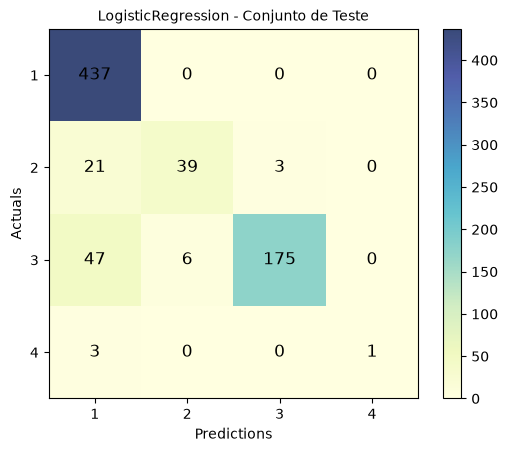


────────────────────────────────────────────────────────────────────────────────
Modelo: KNeighbors
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.80      0.98      0.88       437
           2       0.71      0.51      0.59        63
           3       0.92      0.61      0.73       228
           4       0.00      0.00      0.00         4

    accuracy                           0.82       732
   macro avg       0.61      0.52      0.55       732
weighted avg       0.82      0.82      0.80       732


Matriz de Confusão:
[[427   1   9   0]
 [ 28  32   3   0]
 [ 78  12 138   0]
 [  4   0   0   0]]


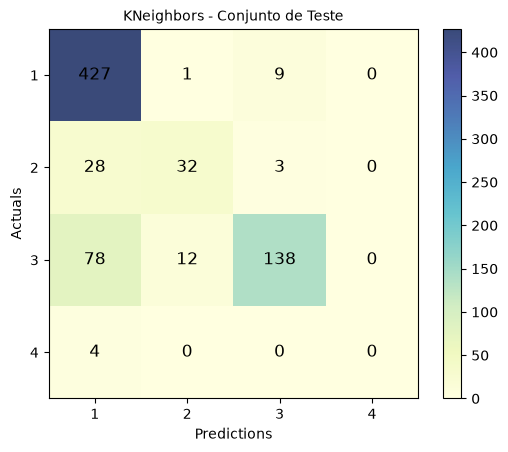


────────────────────────────────────────────────────────────────────────────────
Modelo: SVC
────────────────────────────────────────────────────────────────────────────────



Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.76      0.92      0.84       437
           2       0.00      0.00      0.00        63
           3       0.65      0.57      0.61       228
           4       0.00      0.00      0.00         4

    accuracy                           0.73       732
   macro avg       0.35      0.37      0.36       732
weighted avg       0.66      0.73      0.69       732


Matriz de Confusão:
[[404   0  33   0]
 [ 26   0  37   0]
 [ 97   0 131   0]
 [  2   0   2   0]]


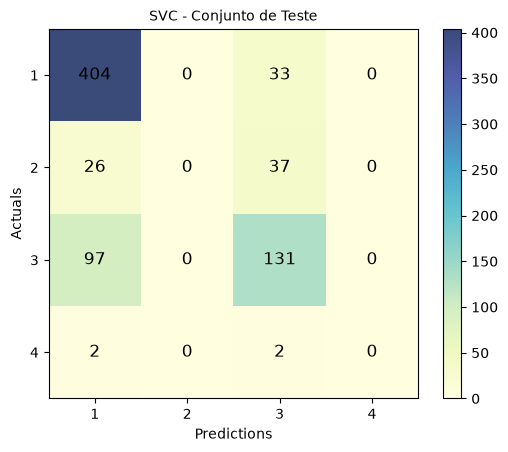


────────────────────────────────────────────────────────────────────────────────
Modelo: DecisionTree
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.96      0.97      0.96       437
           2       0.82      0.89      0.85        63
           3       0.96      0.93      0.95       228
           4       0.33      0.25      0.29         4

    accuracy                           0.95       732
   macro avg       0.77      0.76      0.76       732
weighted avg       0.95      0.95      0.95       732


Matriz de Confusão:
[[423   7   6   1]
 [  4  56   2   1]
 [ 10   5 213   0]
 [  3   0   0   1]]


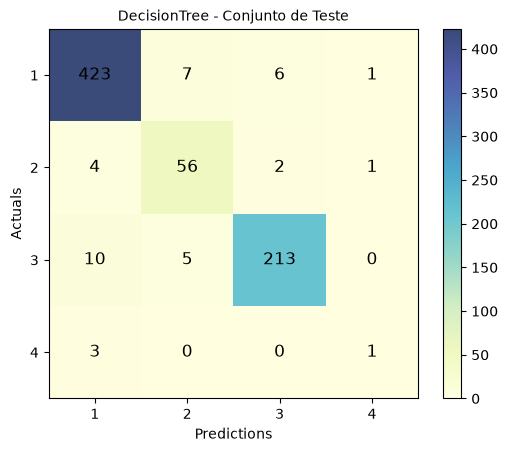


────────────────────────────────────────────────────────────────────────────────
Modelo: ExtraTrees
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.93      0.97      0.95       437
           2       0.83      0.79      0.81        63
           3       0.92      0.87      0.90       228
           4       1.00      0.25      0.40         4

    accuracy                           0.92       732
   macro avg       0.92      0.72      0.77       732
weighted avg       0.92      0.92      0.92       732


Matriz de Confusão:
[[425   0  12   0]
 [  8  50   5   0]
 [ 19  10 199   0]
 [  3   0   0   1]]


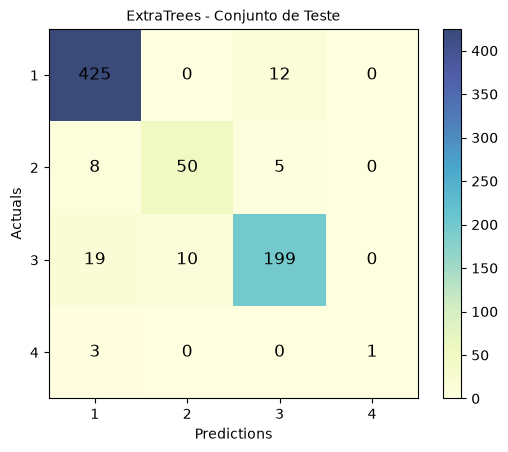


────────────────────────────────────────────────────────────────────────────────
Modelo: RandomForest
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.94      0.98      0.96       437
           2       0.96      0.83      0.89        63
           3       0.95      0.92      0.94       228
           4       0.00      0.00      0.00         4

    accuracy                           0.95       732
   macro avg       0.71      0.68      0.70       732
weighted avg       0.94      0.95      0.94       732


Matriz de Confusão:
[[430   0   7   0]
 [  7  52   4   0]
 [ 16   2 210   0]
 [  4   0   0   0]]


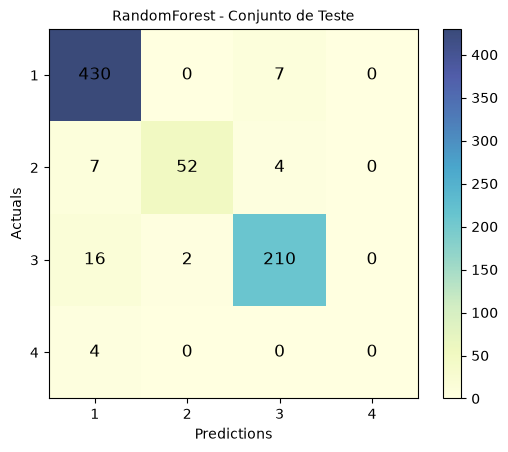


────────────────────────────────────────────────────────────────────────────────
Modelo: GaussianNB
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.78      0.90      0.83       437
           2       0.67      0.03      0.06        63
           3       0.62      0.61      0.61       228
           4       0.00      0.00      0.00         4

    accuracy                           0.73       732
   macro avg       0.52      0.38      0.38       732
weighted avg       0.71      0.73      0.69       732


Matriz de Confusão:
[[393   1  43   0]
 [ 21   2  40   0]
 [ 90   0 138   0]
 [  2   0   2   0]]


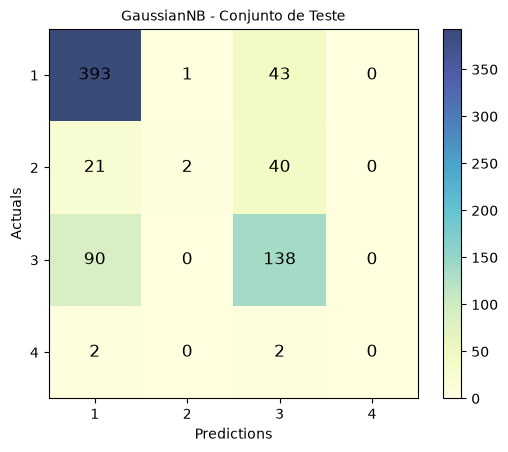


RELATÓRIO RESUMIDO - CONJUNTO DE TESTE
LogisticRegression   | Acc: 0.8907
KNeighbors           | Acc: 0.8156
SVC                  | Acc: 0.7309
DecisionTree         | Acc: 0.9467
ExtraTrees           | Acc: 0.9221
RandomForest         | Acc: 0.9454
GaussianNB           | Acc: 0.7281


COMPARAÇÃO: VALIDAÇÃO CRUZADA vs TESTE

             Model CV_Accuracy Test_Accuracy
LogisticRegression      0.8705        0.8907
        KNeighbors      0.8015        0.8156
               SVC      0.7171        0.7309
      DecisionTree      0.9320        0.9467
        ExtraTrees      0.9218        0.9221
      RandomForest      0.9429        0.9454
        GaussianNB      0.7188        0.7281


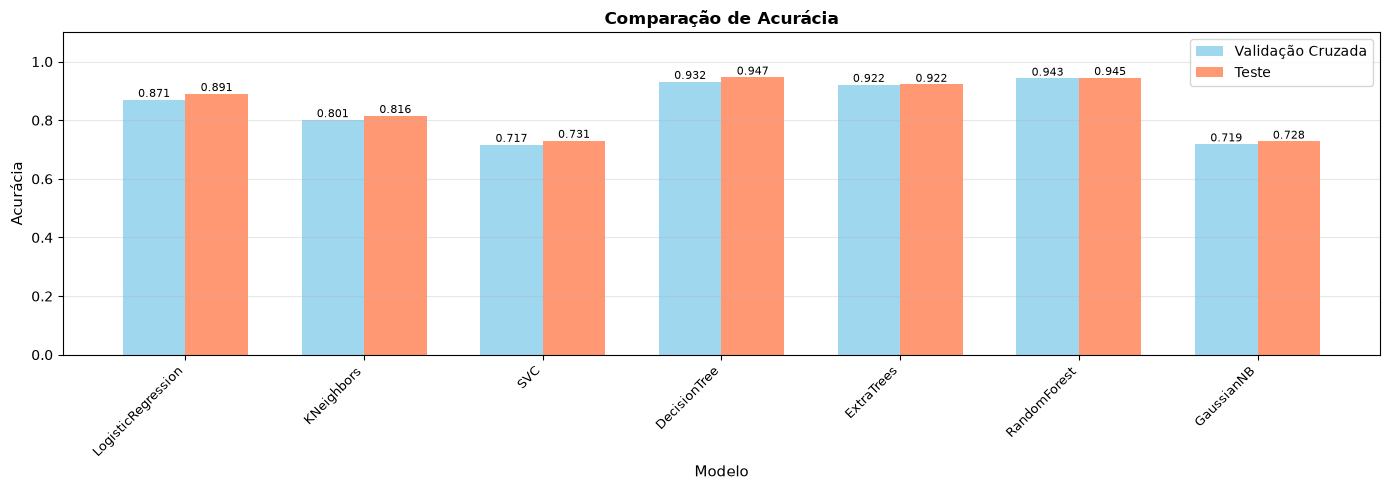


ANÁLISE DE OVERFITTING
LogisticRegression   | CV: 0.8705 | Test: 0.8907 | Diff: -0.0202
KNeighbors           | CV: 0.8015 | Test: 0.8156 | Diff: -0.0141
SVC                  | CV: 0.7171 | Test: 0.7309 | Diff: -0.0138
DecisionTree         | CV: 0.9320 | Test: 0.9467 | Diff: -0.0147
ExtraTrees           | CV: 0.9218 | Test: 0.9221 | Diff: -0.0003
RandomForest         | CV: 0.9429 | Test: 0.9454 | Diff: -0.0025
GaussianNB           | CV: 0.7188 | Test: 0.7281 | Diff: -0.0093


,Model,CV_Accuracy,Test_Accuracy
0,LogisticRegression,0.8705,0.8907
1,KNeighbors,0.8015,0.8156
2,SVC,0.7171,0.7309
3,DecisionTree,0.9320,0.9467
4,ExtraTrees,0.9218,0.9221
5,RandomForest,0.9429,0.9454
6,GaussianNB,0.7188,0.7281


In [29]:
resultados_cv_banda = model_cross_validation(X_train_banda, y_train_banda, pipelines, folds=5, binary_classification=binaryClassification_banda)
trained_pipelines_banda = model_train(X_train_banda, y_train_banda, pipelines, model_dir=f'{pasta_resultados_banda}/models')
test_results_banda = evaluate_on_test(
    X_test_banda,
    y_test_banda,
    trained_pipelines_banda,
    rotulos_dataset_banda,
    binary_classification=binaryClassification_banda,
    result_path=pasta_resultados_banda
)
compare_train_test_performance(resultados_cv_banda, test_results_banda, result_path=pasta_resultados_banda)


# Múltiplos objetivos (mice/elephant)

Usa o histórico consolidado de latência + banda (`historico_telemetria_h1_h6.csv`) e os rótulos multiobjetivo (`rotulos_por_fluxo.txt`), gerados por `gerar_historico_fluxo.py`. Cada timestamp aparece uma vez por categoria de fluxo; a rota "correta" depende da categoria:

- `mice`: rota de menor latência
- `elephant`: rota de maior banda disponível

Como o dataset consolidado tem todas as linhas `mice` primeiro e todas as `elephant` depois, os dados são embaralhados (mantendo X, y e a categoria sincronizados) antes da separação treino/teste e da validação cruzada, para o modelo não ver as categorias agrupadas em blocos.

In [30]:
historico_fluxo = pd.read_csv(f"{pasta_dataset}/{arquivo_historico_fluxo}")

# Mesmo cuidado das seções anteriores: preenche eventuais falhas pontuais de
# leitura (latência ou banda) por interpolação linear antes de montar X/y.
colunas_numericas_fluxo = historico_fluxo.columns.drop(['timestamp', 'categoria'])
faltantes_fluxo = historico_fluxo[colunas_numericas_fluxo].isna().sum().sum()
if faltantes_fluxo:
    print(f"Aviso: {faltantes_fluxo} valores faltantes no histórico multiobjetivo — preenchidos por interpolação linear.")
    historico_fluxo[colunas_numericas_fluxo] = historico_fluxo[colunas_numericas_fluxo].interpolate(method='linear', limit_direction='both')

rotulos_fluxo = np.loadtxt(f"{pasta_dataset}/{arquivo_rotulos_fluxo}", comments='#', dtype=int)

colunas_latencia = [coluna for coluna in historico_fluxo.columns if coluna.startswith('latencia_')]
colunas_banda = [coluna for coluna in historico_fluxo.columns if coluna.startswith('banda_')]

fluxo_datetimes = historico_fluxo.iloc[:, 0].values
fluxo_datetimes_dt = pd.to_datetime(fluxo_datetimes)

fluxo_temporal_features = np.column_stack([
    fluxo_datetimes_dt.hour,
    fluxo_datetimes_dt.minute,
    fluxo_datetimes_dt.second,
    fluxo_datetimes_dt.day,
    fluxo_datetimes_dt.month,
    fluxo_datetimes_dt.year
])

latencia_por_rota_fluxo = historico_fluxo[colunas_latencia].values
banda_por_rota_fluxo = historico_fluxo[colunas_banda].values
categoria_fluxo = historico_fluxo['categoria'].values

# Codifica a categoria como feature numérica: o rótulo correto de uma mesma
# linha de telemetria depende de qual categoria de fluxo ela representa
categorias_unicas = sorted(np.unique(categoria_fluxo))
categoria_para_id = {categoria: indice for indice, categoria in enumerate(categorias_unicas)}
categoria_codificada = np.array([[categoria_para_id[c]] for c in categoria_fluxo])

print(f"Categorias: {categoria_para_id}")

X_fluxo = np.hstack([fluxo_temporal_features, latencia_por_rota_fluxo, banda_por_rota_fluxo, categoria_codificada])
y_fluxo = rotulos_fluxo

print(f"Shape X_fluxo: {X_fluxo.shape}")
print(pd.Series(categoria_fluxo).value_counts())


Aviso: 4 valores faltantes no histórico multiobjetivo — preenchidos por interpolação linear.
Categorias: {'elephant': 0, 'mice': 1}
Shape X_fluxo: (7316, 15)
mice        3658
elephant    3658
Name: count, dtype: int64


In [31]:
# As linhas do histórico multiobjetivo estão agrupadas por categoria (todas
# as 'mice' primeiro, depois todas as 'elephant'). Embaralha X, y e a
# categoria juntos (mesma permutação) para misturar as categorias antes do
# treino/teste e da validação cruzada.
X_fluxo, y_fluxo, categoria_fluxo = shuffle(X_fluxo, y_fluxo, categoria_fluxo, random_state=1234)

print("Categorias após o shuffle (primeiras 20 linhas):")
print(categoria_fluxo[:20])


Categorias após o shuffle (primeiras 20 linhas):
<StringArray>
[    'mice',     'mice', 'elephant',     'mice', 'elephant',     'mice',
 'elephant', 'elephant',     'mice',     'mice',     'mice',     'mice',
     'mice', 'elephant', 'elephant',     'mice', 'elephant',     'mice',
 'elephant',     'mice']
Length: 20, dtype: str


In [32]:
pasta_resultados_fluxo = f"{RESULTS_FOLDER}/CenarioMultiObjetivo_{DATASET}"
os.makedirs(pasta_resultados_fluxo, exist_ok=True)

rotulos_dataset_fluxo = np.unique(y_fluxo).tolist()
binaryClassification_fluxo = len(rotulos_dataset_fluxo) <= 2

X_train_fluxo, X_test_fluxo, y_train_fluxo, y_test_fluxo = train_test_split(
    X_fluxo, y_fluxo,
    test_size=0.2,
    random_state=1234,
    shuffle=True,
    stratify=None
)

print(f"Total de amostras: {len(y_fluxo)}\n")
print(f"Classes únicas:\t\t{rotulos_dataset_fluxo}")
print(f"Classes em y_train_fluxo:\t{np.unique(y_train_fluxo)}")
print(f"Classes em y_test_fluxo:\t{np.unique(y_test_fluxo)}")

print("\nDistribuição das classes:")
print(pd.Series(y_fluxo).value_counts())


Total de amostras: 7316

Classes únicas:		[1, 2, 3, 4]
Classes em y_train_fluxo:	[1 2 3 4]
Classes em y_test_fluxo:	[1 2 3 4]

Distribuição das classes:
4    3073
1    2290
3    1557
2     396
Name: count, dtype: int64


VALIDAÇÃO CRUZADA NO CONJUNTO DE TREINO (Stratified K-Fold)


LogisticRegression   | Acc: 0.8416 ± 0.0104


KNeighbors           | Acc: 0.4903 ± 0.0092


SVC                  | Acc: 0.4236 ± 0.0008


DecisionTree         | Acc: 0.9634 ± 0.0042


ExtraTrees           | Acc: 0.9347 ± 0.0070


RandomForest         | Acc: 0.9598 ± 0.0031
GaussianNB           | Acc: 0.8346 ± 0.0146


AVALIAÇÃO NO CONJUNTO DE TESTE (DADOS NÃO VISTOS)


────────────────────────────────────────────────────────────────────────────────
Modelo: LogisticRegression
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.74      0.89      0.81       458
           2       0.67      0.45      0.54        87
           3       0.81      0.62      0.70       299
           4       0.93      0.94      0.94       620

    accuracy                           0.83      1464
   macro avg       0.79      0.72      0.75      1464
weighted avg       0.83      0.83      0.82      1464


Matriz de Confusão:
[[409   1  20  28]
 [ 31  39  12   5]
 [ 91  15 184   9]
 [ 23   3  12 582]]


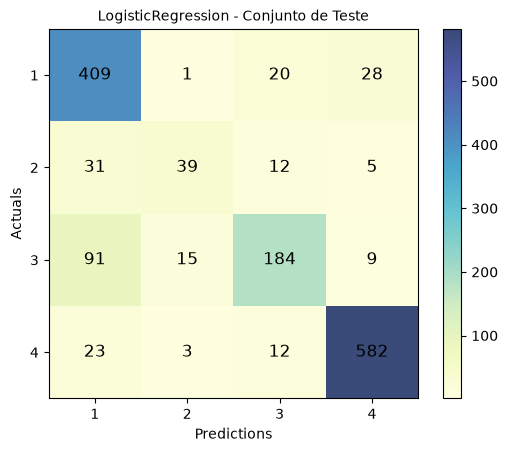


────────────────────────────────────────────────────────────────────────────────
Modelo: KNeighbors
────────────────────────────────────────────────────────────────────────────────



Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.48      0.54      0.51       458
           2       0.28      0.20      0.23        87
           3       0.55      0.51      0.53       299
           4       0.49      0.49      0.49       620

    accuracy                           0.49      1464
   macro avg       0.45      0.43      0.44      1464
weighted avg       0.49      0.49      0.49      1464


Matriz de Confusão:
[[246   2  25 185]
 [ 18  17  16  36]
 [ 43  12 151  93]
 [206  29  82 303]]


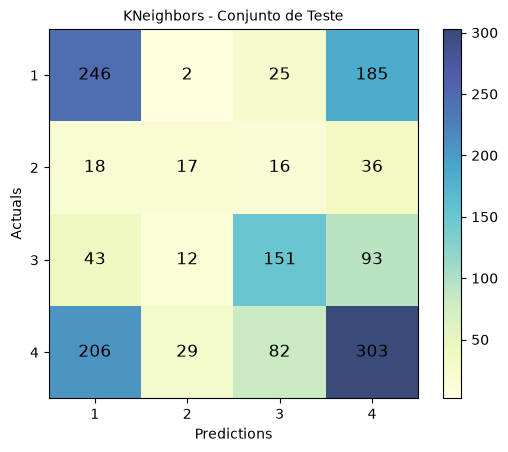


────────────────────────────────────────────────────────────────────────────────
Modelo: SVC
────────────────────────────────────────────────────────────────────────────────



Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       458
           2       0.00      0.00      0.00        87
           3       0.75      0.18      0.30       299
           4       0.44      0.98      0.61       620

    accuracy                           0.45      1464
   macro avg       0.30      0.29      0.23      1464
weighted avg       0.34      0.45      0.32      1464


Matriz de Confusão:
[[  0   0   6 452]
 [  0   0   2  85]
 [  0   0  55 244]
 [  0   0  10 610]]


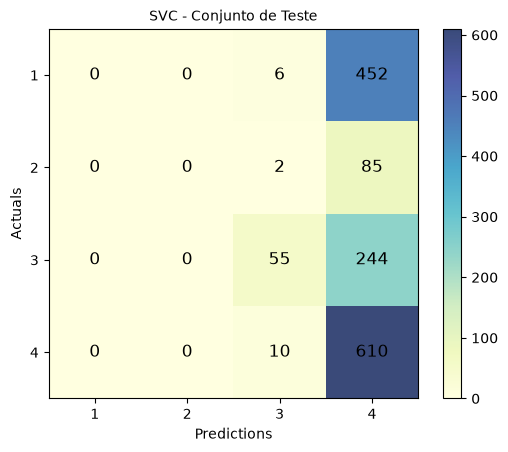


────────────────────────────────────────────────────────────────────────────────
Modelo: DecisionTree
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.97      0.97      0.97       458
           2       0.88      0.86      0.87        87
           3       0.93      0.94      0.94       299
           4       1.00      0.99      0.99       620

    accuracy                           0.97      1464
   macro avg       0.94      0.94      0.94      1464
weighted avg       0.97      0.97      0.97      1464


Matriz de Confusão:
[[444   3  10   1]
 [  2  75  10   0]
 [  9   6 282   2]
 [  3   1   2 614]]


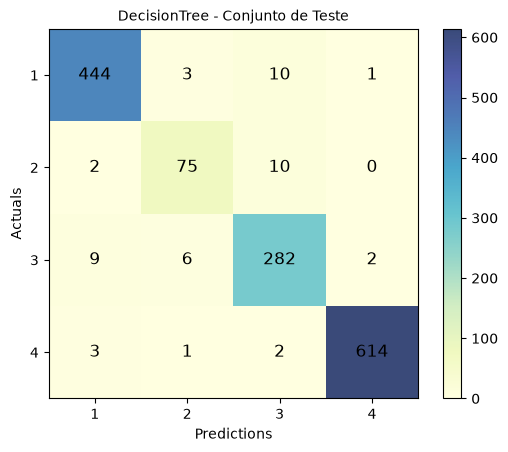


────────────────────────────────────────────────────────────────────────────────
Modelo: ExtraTrees
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.92      0.97      0.94       458
           2       0.93      0.72      0.81        87
           3       0.90      0.89      0.90       299
           4       0.98      0.99      0.98       620

    accuracy                           0.94      1464
   macro avg       0.93      0.89      0.91      1464
weighted avg       0.94      0.94      0.94      1464


Matriz de Confusão:
[[442   0  10   6]
 [  7  63  16   1]
 [ 24   5 265   5]
 [  5   0   2 613]]


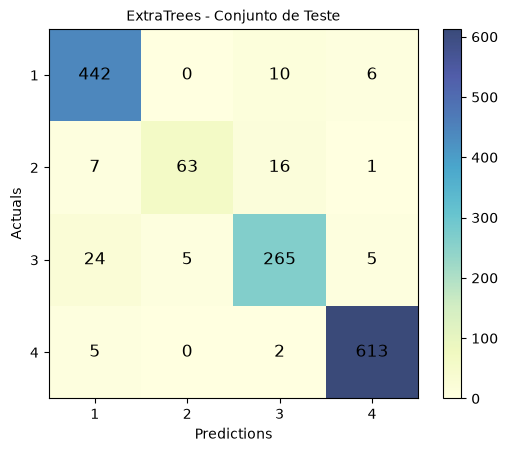


────────────────────────────────────────────────────────────────────────────────
Modelo: RandomForest
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.95      0.97      0.96       458
           2       0.96      0.83      0.89        87
           3       0.91      0.94      0.92       299
           4       1.00      0.98      0.99       620

    accuracy                           0.96      1464
   macro avg       0.95      0.93      0.94      1464
weighted avg       0.96      0.96      0.96      1464


Matriz de Confusão:
[[446   0  12   0]
 [  6  72   9   0]
 [ 14   3 280   2]
 [  5   0   6 609]]


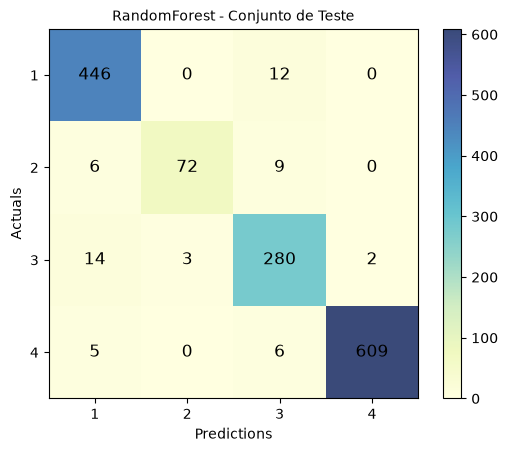


────────────────────────────────────────────────────────────────────────────────
Modelo: GaussianNB
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.78      0.86      0.82       458
           2       0.49      0.47      0.48        87
           3       0.73      0.67      0.70       299
           4       0.99      0.96      0.97       620

    accuracy                           0.84      1464
   macro avg       0.75      0.74      0.74      1464
weighted avg       0.84      0.84      0.84      1464


Matriz de Confusão:
[[395  22  40   1]
 [ 33  41  13   0]
 [ 73  19 199   8]
 [  6   1  20 593]]


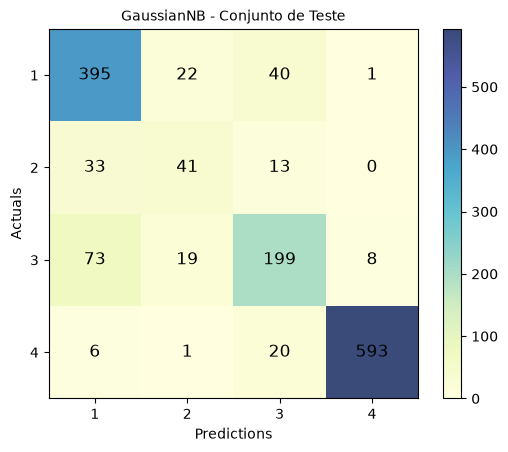


RELATÓRIO RESUMIDO - CONJUNTO DE TESTE
LogisticRegression   | Acc: 0.8292
KNeighbors           | Acc: 0.4898
SVC                  | Acc: 0.4542
DecisionTree         | Acc: 0.9665
ExtraTrees           | Acc: 0.9447
RandomForest         | Acc: 0.9611
GaussianNB           | Acc: 0.8388


COMPARAÇÃO: VALIDAÇÃO CRUZADA vs TESTE

             Model CV_Accuracy Test_Accuracy
LogisticRegression      0.8416        0.8292
        KNeighbors      0.4903        0.4898
               SVC      0.4236        0.4542
      DecisionTree      0.9634        0.9665
        ExtraTrees      0.9347        0.9447
      RandomForest      0.9598        0.9611
        GaussianNB      0.8346        0.8388


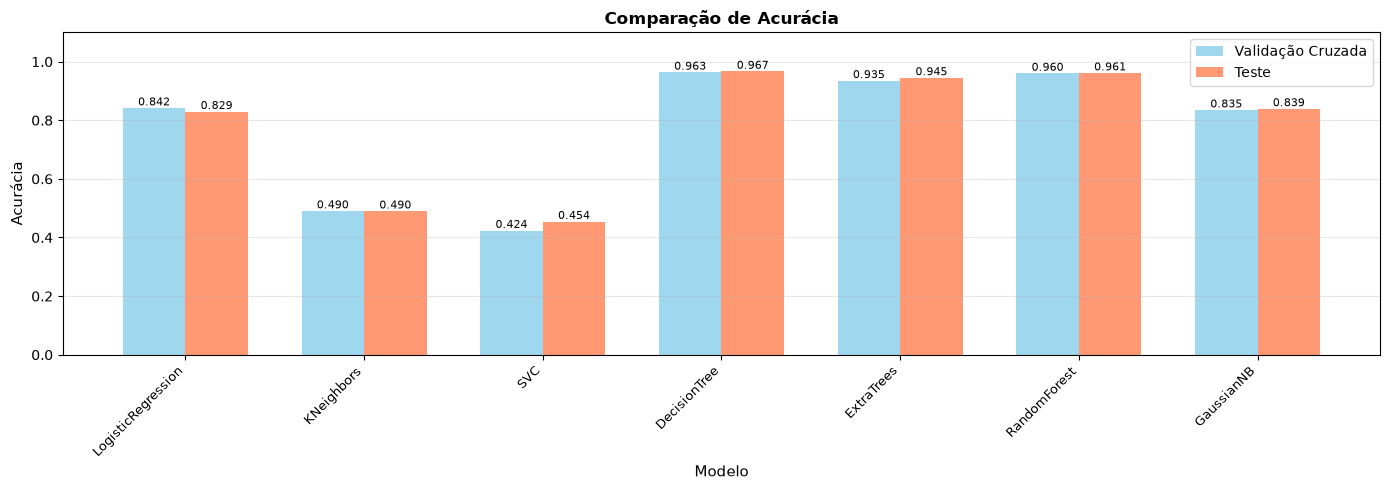


ANÁLISE DE OVERFITTING
LogisticRegression   | CV: 0.8416 | Test: 0.8292 | Diff: +0.0124
KNeighbors           | CV: 0.4903 | Test: 0.4898 | Diff: +0.0005
SVC                  | CV: 0.4236 | Test: 0.4542 | Diff: -0.0306
DecisionTree         | CV: 0.9634 | Test: 0.9665 | Diff: -0.0031
ExtraTrees           | CV: 0.9347 | Test: 0.9447 | Diff: -0.0100
RandomForest         | CV: 0.9598 | Test: 0.9611 | Diff: -0.0013
GaussianNB           | CV: 0.8346 | Test: 0.8388 | Diff: -0.0042


,Model,CV_Accuracy,Test_Accuracy
0,LogisticRegression,0.8416,0.8292
1,KNeighbors,0.4903,0.4898
2,SVC,0.4236,0.4542
3,DecisionTree,0.9634,0.9665
4,ExtraTrees,0.9347,0.9447
5,RandomForest,0.9598,0.9611
6,GaussianNB,0.8346,0.8388


In [33]:
resultados_cv_fluxo = model_cross_validation(X_train_fluxo, y_train_fluxo, pipelines, folds=5, binary_classification=binaryClassification_fluxo)
trained_pipelines_fluxo = model_train(X_train_fluxo, y_train_fluxo, pipelines, model_dir=f'{pasta_resultados_fluxo}/models')
test_results_fluxo = evaluate_on_test(
    X_test_fluxo,
    y_test_fluxo,
    trained_pipelines_fluxo,
    rotulos_dataset_fluxo,
    binary_classification=binaryClassification_fluxo,
    result_path=pasta_resultados_fluxo
)
compare_train_test_performance(resultados_cv_fluxo, test_results_fluxo, result_path=pasta_resultados_fluxo)


# Múltiplos objetivos — versão robusta

Reaproveita o mesmo histórico consolidado (latência + banda + categoria), mas ataca os três problemas identificados na análise dos resultados em D4c:

1. **Escala**: `StandardScaler` dentro do pipeline de cada modelo — sem isso, a banda (faixa 0–100) dominava a distância/kernel de KNN e SVC sobre a categoria (0/1), fazendo esses modelos praticamente ignorarem qual objetivo (mice/elephant) se aplicava.
2. **Desbalanceamento**: `class_weight='balanced'` nos modelos que suportam o parâmetro (Logistic Regression, SVC, árvores) — a classe minoritária (Vermelho, ~2% dos dados) tinha recall baixíssimo mesmo nos melhores modelos da seção anterior.
3. **Features temporais mortas**: hora/dia/mês/ano trocados por um único `elapsed_seconds` (segundos desde o início da coleta) — dia/mês/ano são constantes dentro de cada arquivo (uma única sessão de coleta) e não carregam informação nenhuma.
4. **Vazamento temporal**: em vez de um split aleatório — onde timestamps vizinhos, com condições de rede quase idênticas, podem cair ao mesmo tempo em treino e teste — o split aqui é **cronológico por categoria**: os primeiros 80% de cada categoria (mice/elephant), na ordem em que ocorreram, vão para o treino; os últimos 20% para o teste. Isso mede generalização real ao longo do tempo, não memorização de instantes próximos.

Os resultados desta seção não são diretamente comparáveis aos da seção anterior — o split é diferente por construção (cronológico vs. aleatório) — mas mostram se o modelo generaliza para o "futuro" da mesma coleta, que é o cenário real de uso (treinar com o histórico, prever o próximo instante).

In [34]:
historico_fluxo_robusto = pd.read_csv(f"{pasta_dataset}/{arquivo_historico_fluxo}")
rotulos_fluxo_robusto = np.loadtxt(f"{pasta_dataset}/{arquivo_rotulos_fluxo}", comments='#', dtype=int)

colunas_latencia_robusto = [c for c in historico_fluxo_robusto.columns if c.startswith('latencia_')]
colunas_banda_robusto = [c for c in historico_fluxo_robusto.columns if c.startswith('banda_')]
colunas_numericas_robusto = colunas_latencia_robusto + colunas_banda_robusto

if historico_fluxo_robusto[colunas_numericas_robusto].isna().any().any():
    print("Aviso: valores faltantes no histórico — preenchidos por interpolação linear.")
    historico_fluxo_robusto[colunas_numericas_robusto] = (
        historico_fluxo_robusto[colunas_numericas_robusto]
        .interpolate(method='linear', limit_direction='both')
    )

datetimes_robusto = pd.to_datetime(historico_fluxo_robusto['timestamp'])
elapsed_seconds_robusto = (datetimes_robusto - datetimes_robusto.min()).dt.total_seconds().values.reshape(-1, 1)

latencia_por_rota_robusto = historico_fluxo_robusto[colunas_latencia_robusto].values
banda_por_rota_robusto = historico_fluxo_robusto[colunas_banda_robusto].values
categoria_fluxo_robusto = historico_fluxo_robusto['categoria'].values

# Codifica a categoria como feature numérica (mesma lógica da seção anterior)
categorias_unicas_robusto = sorted(np.unique(categoria_fluxo_robusto))
categoria_para_id_robusto = {categoria: indice for indice, categoria in enumerate(categorias_unicas_robusto)}
categoria_codificada_robusto = np.array([[categoria_para_id_robusto[c]] for c in categoria_fluxo_robusto])

X_robusto = np.hstack([elapsed_seconds_robusto, latencia_por_rota_robusto, banda_por_rota_robusto, categoria_codificada_robusto])
y_robusto = rotulos_fluxo_robusto

print(f"Categorias: {categoria_para_id_robusto}")
print(f"Shape X_robusto: {X_robusto.shape}")
print(f"Intervalo de elapsed_seconds: {elapsed_seconds_robusto.min():.0f}s a {elapsed_seconds_robusto.max():.0f}s")


Aviso: valores faltantes no histórico — preenchidos por interpolação linear.
Categorias: {'elephant': 0, 'mice': 1}
Shape X_robusto: (7316, 10)
Intervalo de elapsed_seconds: 0s a 3659s


In [35]:
def split_temporal_por_categoria(categorias, fracao_treino=0.8):
    """
    Split cronológico (não aleatório) feito separadamente dentro de cada
    categoria: as primeiras 'fracao_treino' linhas de cada categoria (na
    ordem em que aparecem no histórico, ou seja, por tempo) vão para o
    treino, o restante para o teste. Evita que timestamps vizinhos — com
    condições de rede quase idênticas — caiam ao mesmo tempo em treino e
    teste.
    """
    indices_treino, indices_teste = [], []
    for categoria in np.unique(categorias):
        indices_categoria = np.where(categorias == categoria)[0]
        corte = int(len(indices_categoria) * fracao_treino)
        indices_treino.extend(indices_categoria[:corte])
        indices_teste.extend(indices_categoria[corte:])
    return np.array(indices_treino), np.array(indices_teste)

indices_treino_robusto, indices_teste_robusto = split_temporal_por_categoria(categoria_fluxo_robusto)

X_train_robusto, X_test_robusto = X_robusto[indices_treino_robusto], X_robusto[indices_teste_robusto]
y_train_robusto, y_test_robusto = y_robusto[indices_treino_robusto], y_robusto[indices_teste_robusto]
categoria_teste_robusto = categoria_fluxo_robusto[indices_teste_robusto]

rotulos_dataset_robusto = np.unique(y_robusto).tolist()
binaryClassification_robusto = len(rotulos_dataset_robusto) <= 2

print(f"Treino: {len(y_train_robusto)} | Teste: {len(y_test_robusto)}")
print("\nDistribuição das classes no treino:")
print(pd.Series(y_train_robusto).value_counts())
print("\nDistribuição das classes no teste:")
print(pd.Series(y_test_robusto).value_counts())
print("\nCategorias no teste:")
print(pd.Series(categoria_teste_robusto).value_counts())


Treino: 5852 | Teste: 1464

Distribuição das classes no treino:
4    2542
1    1788
3    1196
2     326
Name: count, dtype: int64

Distribuição das classes no teste:
4    531
1    502
3    361
2     70
Name: count, dtype: int64

Categorias no teste:
elephant    732
mice        732
Name: count, dtype: int64


In [36]:
# Mesmos 7 modelos das seções anteriores, mas com class_weight='balanced' nos
# que suportam o parâmetro (compensa a classe minoritária) e um StandardScaler
# antes do classificador (evita que a banda, com faixa 0-100, domine a
# distância/kernel de KNN e SVC sobre a categoria, que é só 0/1).
modelos_robustos = [
    ('LogisticRegression', LogisticRegression(max_iter=1000, class_weight='balanced')),
    ('KNeighbors', KNeighborsClassifier()),
    ('SVC', svm.SVC(probability=True, class_weight='balanced')),
    ('DecisionTree', tree.DecisionTreeClassifier(class_weight='balanced')),
    ('ExtraTrees', ExtraTreesClassifier(class_weight='balanced')),
    ('RandomForest', RandomForestClassifier(class_weight='balanced')),
    ('GaussianNB', GaussianNB())
]

pipelines_robustos = {}
for nome_modelo, modelo in modelos_robustos:
    pipelines_robustos[nome_modelo] = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('classifier', modelo)
    ])


VALIDAÇÃO CRUZADA NO CONJUNTO DE TREINO (Stratified K-Fold)


LogisticRegression   | Acc: 0.8633 ± 0.0127


KNeighbors           | Acc: 0.8766 ± 0.0061


SVC                  | Acc: 0.8756 ± 0.0067


DecisionTree         | Acc: 0.9617 ± 0.0050


ExtraTrees           | Acc: 0.9528 ± 0.0030


RandomForest         | Acc: 0.9663 ± 0.0023


GaussianNB           | Acc: 0.8395 ± 0.0097


AVALIAÇÃO NO CONJUNTO DE TESTE (DADOS NÃO VISTOS)


────────────────────────────────────────────────────────────────────────────────
Modelo: LogisticRegression
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.80      0.82      0.81       502
           2       0.39      0.69      0.49        70
           3       0.82      0.69      0.75       361
           4       0.98      0.98      0.98       531

    accuracy                           0.84      1464
   macro avg       0.75      0.79      0.76      1464
weighted avg       0.85      0.84      0.84      1464


Matriz de Confusão:
[[410  42  48   2]
 [ 20  48   2   0]
 [ 74  32 249   6]
 [  7   2   4 518]]


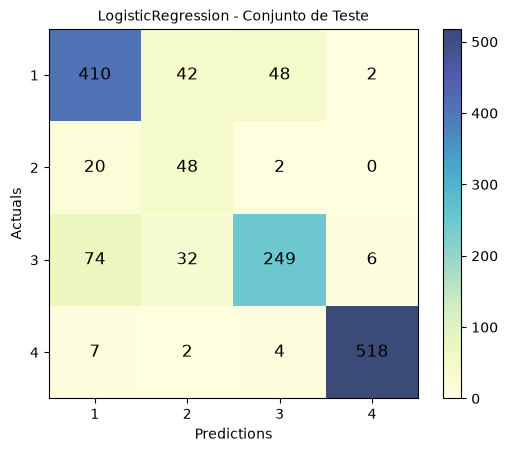


────────────────────────────────────────────────────────────────────────────────
Modelo: KNeighbors
────────────────────────────────────────────────────────────────────────────────



Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.80      0.86      0.83       502
           2       0.48      0.49      0.48        70
           3       0.79      0.66      0.72       361
           4       0.95      0.98      0.97       531

    accuracy                           0.84      1464
   macro avg       0.75      0.75      0.75      1464
weighted avg       0.84      0.84      0.84      1464


Matriz de Confusão:
[[434   6  55   7]
 [ 30  34   6   0]
 [ 74  30 238  19]
 [  7   1   2 521]]


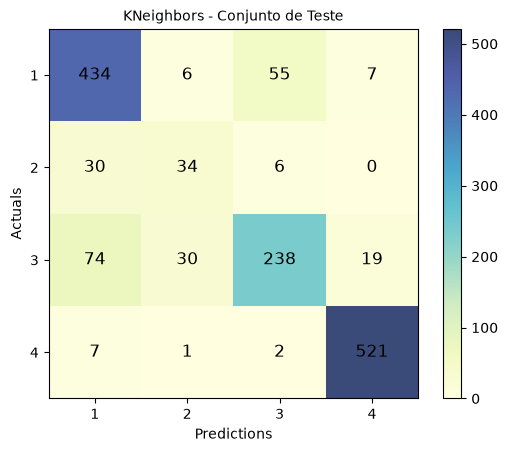


────────────────────────────────────────────────────────────────────────────────
Modelo: SVC
────────────────────────────────────────────────────────────────────────────────



Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.84      0.88      0.86       502
           2       0.40      0.63      0.49        70
           3       0.87      0.72      0.79       361
           4       0.98      0.98      0.98       531

    accuracy                           0.87      1464
   macro avg       0.77      0.80      0.78      1464
weighted avg       0.88      0.87      0.87      1464


Matriz de Confusão:
[[441  24  33   4]
 [ 23  44   3   0]
 [ 54  40 261   6]
 [  6   1   3 521]]


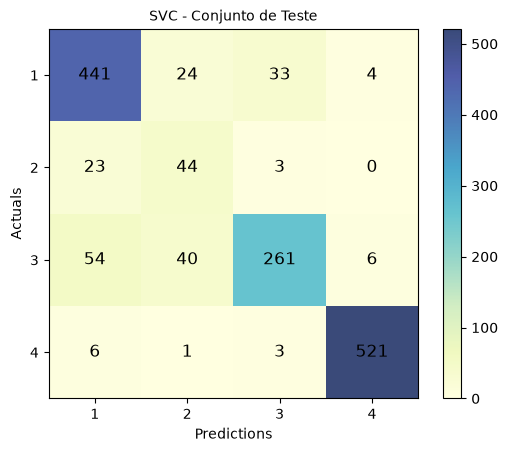


────────────────────────────────────────────────────────────────────────────────
Modelo: DecisionTree
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.95      0.95      0.95       502
           2       0.83      0.81      0.82        70
           3       0.92      0.92      0.92       361
           4       0.98      0.98      0.98       531

    accuracy                           0.95      1464
   macro avg       0.92      0.92      0.92      1464
weighted avg       0.95      0.95      0.95      1464


Matriz de Confusão:
[[477   3  15   7]
 [  4  57   9   0]
 [ 19   9 331   2]
 [  4   0   5 522]]


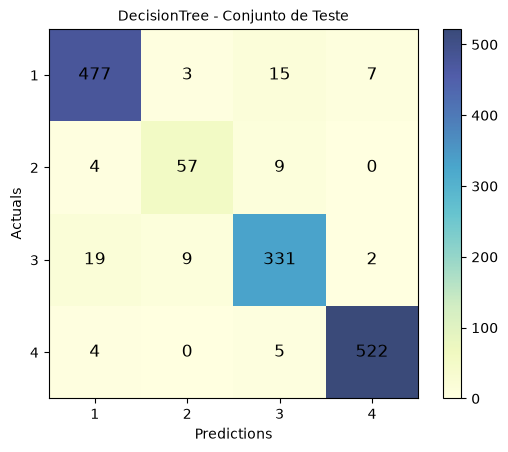


────────────────────────────────────────────────────────────────────────────────
Modelo: ExtraTrees
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.92      0.94      0.93       502
           2       0.84      0.70      0.77        70
           3       0.90      0.88      0.89       361
           4       0.97      0.98      0.98       531

    accuracy                           0.93      1464
   macro avg       0.91      0.88      0.89      1464
weighted avg       0.93      0.93      0.93      1464


Matriz de Confusão:
[[474   0  22   6]
 [ 12  49   9   0]
 [ 24   9 318  10]
 [  6   0   3 522]]


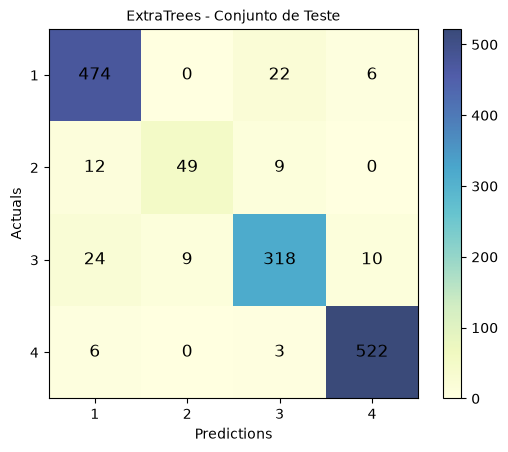


────────────────────────────────────────────────────────────────────────────────
Modelo: RandomForest
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.94      0.96      0.95       502
           2       0.89      0.77      0.82        70
           3       0.92      0.93      0.93       361
           4       0.99      0.98      0.98       531

    accuracy                           0.95      1464
   macro avg       0.93      0.91      0.92      1464
weighted avg       0.95      0.95      0.95      1464


Matriz de Confusão:
[[483   0  18   1]
 [  9  54   7   0]
 [ 14   7 337   3]
 [  8   0   5 518]]


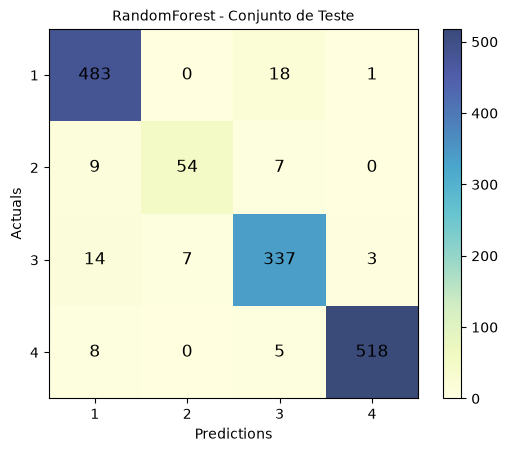


────────────────────────────────────────────────────────────────────────────────
Modelo: GaussianNB
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.77      0.76      0.77       502
           2       0.30      0.34      0.32        70
           3       0.69      0.66      0.68       361
           4       0.96      0.97      0.97       531

    accuracy                           0.79      1464
   macro avg       0.68      0.69      0.68      1464
weighted avg       0.80      0.79      0.79      1464


Matriz de Confusão:
[[384  35  78   5]
 [ 26  24  20   0]
 [ 85  21 240  15]
 [  6   1  10 514]]


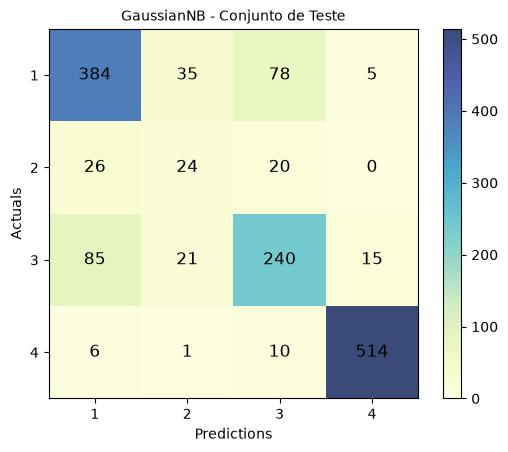


RELATÓRIO RESUMIDO - CONJUNTO DE TESTE
LogisticRegression   | Acc: 0.8367
KNeighbors           | Acc: 0.8381
SVC                  | Acc: 0.8654
DecisionTree         | Acc: 0.9474
ExtraTrees           | Acc: 0.9310
RandomForest         | Acc: 0.9508
GaussianNB           | Acc: 0.7937


COMPARAÇÃO: VALIDAÇÃO CRUZADA vs TESTE

             Model CV_Accuracy Test_Accuracy
LogisticRegression      0.8633        0.8367
        KNeighbors      0.8766        0.8381
               SVC      0.8756        0.8654
      DecisionTree      0.9617        0.9474
        ExtraTrees      0.9528        0.9310
      RandomForest      0.9663        0.9508
        GaussianNB      0.8395        0.7937


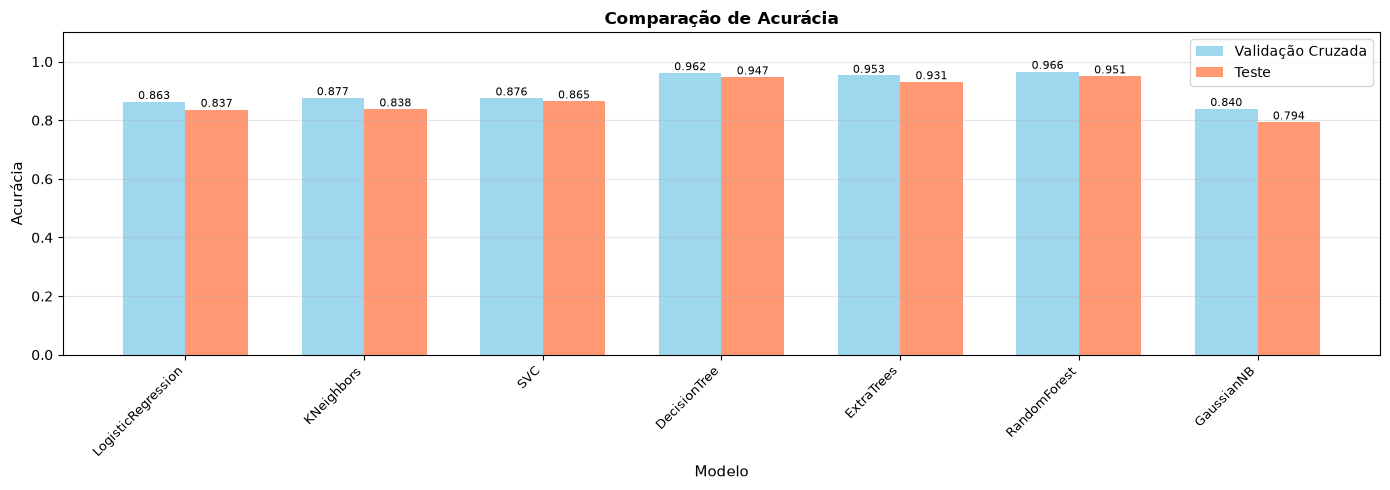


ANÁLISE DE OVERFITTING
LogisticRegression   | CV: 0.8633 | Test: 0.8367 | Diff: +0.0266
KNeighbors           | CV: 0.8766 | Test: 0.8381 | Diff: +0.0385
SVC                  | CV: 0.8756 | Test: 0.8654 | Diff: +0.0102
DecisionTree         | CV: 0.9617 | Test: 0.9474 | Diff: +0.0143
ExtraTrees           | CV: 0.9528 | Test: 0.9310 | Diff: +0.0218
RandomForest         | CV: 0.9663 | Test: 0.9508 | Diff: +0.0155
GaussianNB           | CV: 0.8395 | Test: 0.7937 | Diff: +0.0458


,Model,CV_Accuracy,Test_Accuracy
0,LogisticRegression,0.8633,0.8367
1,KNeighbors,0.8766,0.8381
2,SVC,0.8756,0.8654
3,DecisionTree,0.9617,0.9474
4,ExtraTrees,0.9528,0.9310
5,RandomForest,0.9663,0.9508
6,GaussianNB,0.8395,0.7937


In [37]:
pasta_resultados_robusto = f"{RESULTS_FOLDER}/CenarioMultiObjetivoRobusto_{DATASET}"
os.makedirs(pasta_resultados_robusto, exist_ok=True)

resultados_cv_robusto = model_cross_validation(X_train_robusto, y_train_robusto, pipelines_robustos, folds=5, binary_classification=binaryClassification_robusto)
trained_pipelines_robusto = model_train(X_train_robusto, y_train_robusto, pipelines_robustos, model_dir=f'{pasta_resultados_robusto}/models')
test_results_robusto = evaluate_on_test(
    X_test_robusto,
    y_test_robusto,
    trained_pipelines_robusto,
    rotulos_dataset_robusto,
    binary_classification=binaryClassification_robusto,
    result_path=pasta_resultados_robusto
)
compare_train_test_performance(resultados_cv_robusto, test_results_robusto, result_path=pasta_resultados_robusto)
